# run all neccessary functionalities

In [111]:


def extract_stock_data(df, tdickers, start, end):
    """
    Extract stock data for specific tickers between the start and end dates.

    Parameters:
    - df: pandas DataFrame with rows as dates (monthly) and columns as stock tickers.
    - tickers: list of tickers to extract data for.
    - start: start date (YYYY-MM-DD) for the data extraction.
    - end: end date (YYYY-MM-DD) for the data extraction.

    Returns:
    - pandas DataFrame with the specified tickers and date range.
    """
    # Ensure the date column is in datetime format
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    # Filter the DataFrame for the date range
    df_filtered = df.loc[start:end]

    # Select the tickers from the DataFrame
    df_selected = df_filtered[tdickers]
    df_selected=df_selected.loc[:, df_selected.isna().sum() <= 0].dropna()
    # df_selected.interpolate(method='linear',inplace=True)
    df_selected.index = pd.to_datetime(df_selected.index)
    df_selected = df_selected.tz_localize(None)
    columns = sorted([col for col in df_selected.columns if col != 'Date'])
    df_selected=df_selected[columns]
    for col in df_selected.columns:
        try:
            df_selected[col] = df_selected[col].astype(float)
        except ValueError:
            print()
            #print(f"Column '{col}' could not be converted to float.")
    df_selected.index=df_selected.index.to_period('M').to_timestamp('D')
    df_selected.replace('C', np.nan, inplace=True)
    for col in df_selected.columns:
            try:
                df_selected[col] = df_selected[col].astype(float)
            except ValueError:
                print()
               # print(f"Column '{col}' could not be converted to float.")
    df_selected.interpolate(method='linear',inplace=True)
    df_selected = df_selected.fillna(method='ffill')
    df_selected = df_selected.fillna(method='bfill')
    return df_selected



In [112]:


def extract_spy_data(df, start, end):
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    df_filtered = df.loc[start:end]
    return df_filtered



In [114]:
# Creates tickers ([]), monthly_data (DF), and base_w ([])
def get_spy2(start,end):

    ### Get tickers + setup
    global tickers,spy
    valid_tickers = []

    new_monthly_data1 = new_monthly_data.copy()
    new_monthly_data1.index = pd.to_datetime(new_monthly_data1.index)
    
    spy_year1 = pd.to_datetime(start).year
    spy_year2 = min(spy_year1 + 4, 2024)

    subset = spy_yoy_tickers.loc[str(spy_year1):str(spy_year2)]
    sets = [set(row.dropna()) for _, row in subset.iterrows()]
    candidate = set.intersection(*sets) if sets else set()

    # keep only columns that exist
    candidate = list(candidate.intersection(new_monthly_data.columns))

    # one slice, one NA check across all candidate tickers
    window = new_monthly_data.loc[str(spy_year1):str(spy_year2), candidate]
    valid_tickers = window.columns[~window.isna().any(axis=0)].tolist()

    tickers = valid_tickers
    
    
    ### Import the monthly data
    global monthly_data
    global base_w
    monthly_data = extract_stock_data(new_monthly_data,tickers,start=start,end=end)
    
    # Assign equal weight as base weights
    base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
    base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])

    spy=extract_spy_data(indexgspc,start,end)
    if monthly_data.index.equals(spy.index)==True:
        for i,j in monthly_data.iterrows():
            monthly_data.loc[i,'SP_500']=spy.loc[i,'SP_500']
    # Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    tickers = list(monthly_data.columns[:-1]) 

In [115]:



def download_with_retry(tickers, start, end, retries=3, delay=5):
    for attempt in range(retries):
        try:
            return extract_stock_data(new_monthly_data,tickers, start=start, end=end)
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(delay)
    raise Exception(f"Failed to download data after {retries} attempts.")




In [116]:
def famafrenchreturns():
    global ff3_monthly
    ff3_monthly = pd.read_csv('ff3_wrds.csv')
    ff3_monthly.set_index(ff3_monthly['dateff'], inplace=True)
    ff3_monthly.index.name = 'Date'
    ff3_monthly = ff3_monthly.drop(columns={'dateff'})
    ff3_monthly.columns = 'Mkt-RF','SMB','HML','RF'
    ff3_monthly.index = pd.to_datetime(ff3_monthly.index)
    ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
    # Keeping Only the Dates in the monthly_data
    ff3_monthly = ff3_monthly.loc[monthly_data.index]
    

In [117]:
def to__cal_stock_betas():
    global stock_betas
    stock_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in monthly_data.columns:
        # Set the dependent variable (Return of stock i)
        y = monthly_data[col]
        # Set the independent variables (Fama French 3 Factors)
        X = ff3_monthly[['Mkt-RF','SMB','HML']]
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        stock_betas[col] = [model.intercept_] + list(model.coef_)
    stock_betas = stock_betas.T
    stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [118]:
def to_cal_stock_price(startt,endd):
    global stock_price
    global s_price
    global s_keys
    global s_values
    #Stock Prices on the Day of Optimization(Rebalancing)
    stock_price = extract_stock_data(price_monthly_data,tickers,start=startt,end=endd)
    stock_price = stock_price[-1:]
    stock_price.index = pd.to_datetime(stock_price.index).tz_localize(None)
    s_price = {}
    s_keys = list(tickers)
    s_values =  list(stock_price.iloc[0])
    for key,value in zip(s_keys,s_values):
        s_price[key] = value

In [119]:
def Transaction_Costs(initialize=False):
    # if initialize:
    #     print("first draw:", np.random.random())

    global t_cost
    t_cost = {}
    global keys
    keys = list(tickers)
    values = list(random.uniform(.01, .02) for i in range(len(tickers)))
    for key, value in zip(keys, values):
        t_cost[key] = value


In [311]:

from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpBinary, PULP_CBC_CMD

def optimization():#new
    new_seed = np.random.randint(0, 1_000_000_000, dtype=int)
    np.random.seed(new_seed)
    random.seed(int(new_seed))

    global index, wei, aux, err, binary

    # --- Local, cached index sets ---
    T = list(monthly_data.index)
    I = list(tickers)

    # --- Precompute numeric arrays (NO pandas .loc inside loops) ---
    # Align everything explicitly on T and I
    rf  = ff3_monthly.loc[T, "RF"].to_numpy(dtype=float)
    mkt = ff3_monthly.loc[T, "Mkt-RF"].to_numpy(dtype=float)
    smb = ff3_monthly.loc[T, "SMB"].to_numpy(dtype=float)
    hml = ff3_monthly.loc[T, "HML"].to_numpy(dtype=float)

    # Excess returns matrix X[t,i] = monthly_data[t,i] - RF[t]
    X = monthly_data.loc[T, I].to_numpy(dtype=float) - rf[:, None]

    # RHS[t] = mkt_opt*Mkt-RF + smb_opt*SMB + hml_opt*HML
    RHS = (mkt_opt * mkt) + (smb_opt * smb) + (hml_opt * hml)

    # Base weights and transaction-cost coefficients
    # base_weights[i] must be indexable by ticker
    base = {i: float(base_weights[i]) for i in I}

    # transaction cost coefficient per unit aux:
    # aux[i] * B * t_cost[i] / s_price[i]
    tc_coef = {i: float(B * t_cost[i] / s_price[i]) for i in I}

    # --- Build model ---
    index = LpProblem("Index", LpMinimize)

    wei    = LpVariable.dicts("Weight", I, lowBound=0)
    aux    = LpVariable.dicts("Y",      I, lowBound=0)
    err    = LpVariable.dicts("Error",  T, lowBound=0)
    binary = LpVariable.dicts("bin",    I, cat=LpBinary)

    # Objective: minimize sum of absolute tracking errors
    index += lpSum(err[t] for t in T)

    # Weights sum to 1
    index += lpSum(wei[i] for i in I) == 1

    # Absolute deviation constraints + L1 bound
    for i in I:
        bw = base[i]
        index += aux[i] >= bw - wei[i]
        index += aux[i] >= wei[i] - bw
    index += lpSum(aux[i] for i in I) <= 1

    # Error term constraints: build portfolio return once per t
    for t_idx, t in enumerate(T):
        port = lpSum(wei[i] * X[t_idx, j] for j, i in enumerate(I))
        rhs  = float(RHS[t_idx])
        index += port - err[t] <= rhs
        index += port + err[t] >= rhs

    # Transaction cost constraint (no per-ticker tr_cost vars)
    index += lpSum(aux[i] * tc_coef[i] for i in I) <= 2000

    # Limit # of stocks in portfolio
    for i in I:
        index += wei[i] <= binary[i]
    index += lpSum(binary[i] for i in I) <= q

    # Solve (explicit CBC, quiet)
    index.solve(PULP_CBC_CMD(msg=False))


In [123]:
def others():
    global sharess
    #Change in number of shares
    sharess = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 's'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 's'] , columns = ['Optimal'])
    sharess
    global tr_cost
    #Transaction Costs
    tr_cost = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
    tr_cost.sum()
    global weii
    #Optimal weights
    weii = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
    weii.sum()
    global auxx
    #Change of weights
    auxx = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
    auxx.sum()
    global errr
    #Error terms
    errr = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
    errr.sum()
    global binary_v
    # Check if Binary Values Constraint works
    binary_v = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
    binary_v.sum()
    global opt_weights 
    # Weights in Optimal Portfolio
    opt_weights = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
    opt_weights.style.format('{:,.2%}'.format)
    global weights_new
    weights_new = pd.DataFrame([v.varValue for v in index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
    global weights
    weights = pd.DataFrame(np.zeros((len(monthly_data.columns[:-1]),3)), index=monthly_data.columns[:-1], columns=['PORTFOLIO Weights','Difference','New Weights'])
    for t in monthly_data.columns[:-1]:
        weights.loc[t][0] = base_w.loc[t]
        weights.loc[t][1] = weights_new.loc[t][0]-base_w.loc[t][0]
        weights.loc[t][2] = weights_new.loc[t]
    weights
    columns_to_remove = ['PORTFOLIO Weights', 'Difference']
    # Specify the column to filter non-zero values
    column_to_filter = 'New Weights'
    # Create a new DataFrame with selected columns and rows where New Weights is not equal to 0
    global opt_portf_weights
    opt_portf_weights = weights.drop(columns=columns_to_remove)[weights[column_to_filter] != 0]




In [124]:
def portfolio_betas():
    # CHECK PORTFOLIO BETAS
   
    global port_betas
    port_returns = pd.DataFrame(np.zeros((len(monthly_data.index),2)), index=monthly_data.index, columns=["SP_500","Optimization"])
    for j in port_returns.index:
        port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
        port_returns.loc[j]['Optimization'] = monthly_data.loc[j,:monthly_data.columns[-2]].dot(weights['New Weights'])
    port_returns = port_returns.merge(ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)
    # Create an empty DataFrame to store the Portfolio Beta
    port_betas = pd.DataFrame(np.zeros((3,4)), index=ff3_monthly.columns[0:3], columns=["SP_500", "Target", "Optimization", "Abs. Diff"])
    port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]# Set the independent variables (Fama French 3 Factors)
    X = port_returns[['Mkt-RF','SMB','HML']]
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['SP_500']# Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['SP_500'] = regr.coef_
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['Optimization']
    # Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['Optimization'] = regr.coef_
    # Abs Difference between Target Betas & Optimal Portfolio Betas
    port_betas["Abs. Diff"] = round(abs(port_betas['Optimization'] - port_betas["Target"]),4)
    port_betas
    return port_betas
    

In [125]:
import time

def timed(name, fn, *args, **kwargs):
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    dt = time.perf_counter() - t0
    print(f"{name:25s} {dt:9.3f} s")
    return out

In [128]:
def simulator(beta1,beta2,beta3,begin,final,budget,number):    
    global start
    global end
    start=begin
    end=final
    
    get_spy2(start,end)
    #Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    global tickers
    tickers = list(monthly_data.columns[:-1])
    tick_index = tickers + ['SP_500']
    

    # TARGET FACTOR BETAS 
    global base_weights
    global mkt_opt
    global smb_opt
    global hml_opt
    global B
    global q
    
    mkt_opt = beta1                          # TARGET MKT BETA - EXPOSURE OF THE NEW PORTFOLIO TO MARKET FACTOR 
    smb_opt = beta2                           # TARGET SMB BETA - EXPOSURE OF THE NEW PORTFOLIO TO SIZE FACTOR 
    hml_opt = beta3                           # TARGET HML BETA - EXPOSURE OF THE NEW PORTFOLIO TO VALUE FACTOR 
    B = budget                             # BUDGET
    q = number                                # NUMBER OF STOCKS IN THE NEW PORTFOLIO
    base_weights = base_w.T*0               # ONLY HAVE THIS LINE OF CODE WHEN YOU ARE CONSTRUCTING THE PORTFOLIO FROM SCRATCH 
    
    famafrenchreturns()
    #to__cal_stock_betas()
    to_cal_stock_price(start,end)
    Transaction_Costs()
    optimization()
    others()
    portfolio_betas()
    opt_portf_weights
    global port_betas
    opt_portf_weights


In [129]:
def out_of_sampless(cccc,dddd):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = cccc
    o1_end_d   = dddd
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,cccc,dddd)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [130]:
def out_of_sample():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    return oos1_new_performance

In [131]:
def out_of_sample():
    global oos1_daily_data,oos1_new_returns
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [132]:
def new_mod_out_of_sample1(hsahs,hsahs2):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = hsahs
    # last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = hsahs2
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [133]:
def mod_out_of_sample1():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = out_of_sample_year_start[1]
    last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = out_of_sample_year_end[last_key]
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [134]:
def mod_out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [135]:
def current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    from datetime import datetime, timedelta
    today = datetime.today()
    one_year_before = today - timedelta(days=365)
    os_start = today - timedelta(days=365)
    two_months_before = os_start - timedelta(days=2*30)
    os_start = two_months_before.replace(day=1)
    one_month_before = today - timedelta(days=30)
    os_end = one_month_before.replace(day=1)
    
    n_year_before = os_start - timedelta(days=(365*n_years))
    n_year_after=n_year_before+timedelta(days=(365*n_years))                           
    os_start=os_start.strftime("%Y-%m-%d")
    os_end=os_end.strftime("%Y-%m-%d")
    n_year_before=n_year_before.strftime("%Y-%m-%d")
    n_year_after=n_year_after.strftime("%Y-%m-%d")
    from datetime import date

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date


In [136]:
def new_date_calculation():
    from datetime import datetime, timedelta
    from datetime import date
    today = datetime.now()
    global out_of_sample_year_start
    global out_of_sample_year_end
    out_of_sample_year_start={}
    out_of_sample_year_end={}
    for year in range(os_years):
        out_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (os_years - year)))
        two_months_before = (out_of_sample_year_start[(year+1)] - relativedelta(months = today.month- 1))
        out_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=out_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        out_of_sample_year_end[(year+1)]=out_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        out_of_sample_year_start[(year+1)]=out_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        out_of_sample_year_end[(year+1)]=out_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")                        
    
    global in_of_sample_year_start
    in_of_sample_year_start={}
    global in_of_sample_year_end
    in_of_sample_year_end={}
    for year in range(in_years):
        in_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * ((in_years+os_years) - year)))
        two_months_before = in_of_sample_year_start[(year+1)] - relativedelta(months = today.month-1)
        in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        in_of_sample_year_end[(year+1)]=in_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        in_of_sample_year_start[(year+1)]=in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        in_of_sample_year_end[(year+1)]=in_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")
    
    inner_in_of_sample_year_start={}
    for year in range(in_years+os_years):
        inner_in_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (in_years+os_years - year)))
        two_months_before = inner_in_of_sample_year_start[(year+1)] - relativedelta(months = today.month-1)
        inner_in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=inner_in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        inner_in_of_sample_year_start[(year+1)]=inner_in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date
    return inner_in_of_sample_year_start

In [137]:
def new_run_with_backtest_rebalance_rlm(inyears,outyears,betaA,betaB,betaC, rebal_freq, adj):
    global start_date
    global end_date
    global os_years,tostorelist,nchecklist
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    global inner_n_year_before_cal
    inner_n_year_before_cal=new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before=in_of_sample_year_start[1]
    n_year_after=in_of_sample_year_end[in_years]
    global newbudget
    newbudget = 1000000
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,newbudget,500)
    global checklist
    global mchecklist
    checklist=[]
    mchecklist=[]
    tostorelist=[]
    global rebalance_opt_weights
    global port_betas_list 
    port_betas_list = []
    rebalance_opt_weights = []
    os_count = 1        
    for k in range(os_years-adj): 
        global os_start
        global os_end
        global oos1_new_performances 
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]

        noos1_new_performance=pd.DataFrame()
        global checklist_1
        new_date_calculation()
        
        checking=out_of_sample()
        tostorelist.append(checking)
        inner_n_year_before=inner_n_year_before_cal[k+1]
        inner_n_year_after=str(pd.to_datetime(out_of_sample_year_end[k+1]) - relativedelta(years=1))
        print('****************** Training Period: **********************')
        print(inner_n_year_before)
        print(inner_n_year_after)
        
        checklist.append(oos1_new_performance)
        
        if(rebal_freq == 'y'):
            
            newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]  
            simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,500)
            rebalance_opt_weights.append(opt_weights)
            if(os_count == os_years-adj):
                checklist=extract_performance(checklist)
                noos1_new_performance=pd.concat(checklist, ignore_index=False)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
            start_date = os_start
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
            end_date = os_end 
        os_count +=1
    for kk in range(os_years-adj): 
        placeholder=noos1_new_performance.index[0]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in noos1_new_performance.index:
            new_spy_performances[kk + 1] = noos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = noos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years-adj] = noos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years-adj] = noos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return noos1_new_performance 
    
            
            
        

In [138]:
def new_run_with_backtest_rebalance(inyears,outyears,betaA,betaB,betaC, rebal_freq):
    global start_date
    global end_date
    global os_years,tostorelist,nchecklist
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    global inner_n_year_before_cal
    inner_n_year_before_cal=new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before=in_of_sample_year_start[1]
    n_year_after=in_of_sample_year_end[in_years]
    global newbudget
    newbudget = 1000000
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,newbudget,500)
    global checklist
    global mchecklist
    checklist=[]
    mchecklist=[]
    tostorelist=[]
    global rebalance_opt_weights
    global port_betas_list 
    port_betas_list = []
    rebalance_opt_weights = []
    os_count = 1   
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performance
        oos1_new_performance={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]

        noos1_new_performance=pd.DataFrame()
        global checklist_1
        new_date_calculation()
        
        checking=out_of_sample()
        tostorelist.append(checking)
        inner_n_year_before=inner_n_year_before_cal[k+1]
        inner_n_year_after=out_of_sample_year_end[k+1]
        checklist.append(oos1_new_performance)
        
        if(rebal_freq == 'y'):
            if(k != 0):
                newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]  
            simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,500)
            rebalance_opt_weights.append(opt_portf_weights)
            if(os_count == os_years):
                checklist=extract_performance(checklist)
                noos1_new_performance=pd.concat(checklist, ignore_index=False)
        if rebal_freq == 'dry':
            newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]
            curr_year = pd.to_datetime(inner_n_year_after).year
            try:
                curr_df = pd.read_csv(f'yrebal_explored_sortino_o1_{curr_year}.csv')
            except:
                print('File DNE')
            curr_df = curr_df.sort_values(by='reward')
            betaA = curr_df.iloc[-1][0]
            betaB = curr_df.iloc[-1][1]
            betaC = curr_df.iloc[-1][2]
            print(f'{betaA}, {betaB}, {betaC} ')
            simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,500)
            rebalance_opt_weights.append(opt_portf_weights)
            if(os_count == os_years):
                checklist=extract_performance(checklist)
                noos1_new_performance=pd.concat(checklist, ignore_index=False)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
            start_date = os_start
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
            end_date = os_end 
        os_count +=1
    for kk in range(os_years): 
        placeholder=noos1_new_performance.index[0]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in noos1_new_performance.index:
            new_spy_performances[kk + 1] = noos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = noos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = noos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = noos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return noos1_new_performance 
    
            
            
        

In [139]:
concatenated_df = pd.concat(oos1_list, axis=1)
averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
averaged_df = pd.DataFrame({
    'SP_500': averaged_df_A,
    'Optimized Portfolio': averaged_df_B
})

In [140]:
def new_run_with_backtest_rebalance_cv(inyears,outyears,betaA,betaB,betaC, rebal_freq):
    global start_date
    global end_date
    global os_years
    global in_years
    global os_months
    os_years=outyears
    os_months = os_years*12
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    inner_n_year_before_cal =new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]
    global rebalance_opt_weights
    global port_betas_list 
    port_betas_list = []
    rebalance_opt_weights = []
    prev_month_perf = 1
    noos1_new_performance=pd.DataFrame()
    global expected_betas
    expected_betas = []
    for k in range(os_months-1):   
        # so base is above, and then first step is to grab the performance of January 2020 (assuming standard run)
        # to add to noos1_perf and to update budget    
        if(rebal_freq == 'm'):
            n_year_before_updated = str(pd.to_datetime(n_year_before) + relativedelta(months=k))
            n_year_after_updated = str(pd.to_datetime(n_year_after) + relativedelta(months=k))
            simulator(betaA,betaB,betaC,n_year_before_updated,n_year_after_updated,1000000*prev_month_perf,50)
            rebalance_opt_weights.append(opt_portf_weights)
            start_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=36))
            end_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=37))
            mperformance = out_of_sampless(start_date1,end_date1).copy()
            snipped_perf = mperformance.iloc[1]
            if(k==0):
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat([noos1_new_performance , first_perf.to_frame().T])
            prev_month_perf = snipped_perf['Optimized Portfolio'] * prev_month_perf
            noos1_new_performance = pd.concat([noos1_new_performance , snipped_perf.to_frame().T])
        if(rebal_freq == 'drm'):
            # print(n_year_after)
            n_year_before_updated = str(pd.to_datetime(n_year_before) + relativedelta(months=k))
            n_year_after_updated = str(pd.to_datetime(n_year_after) + relativedelta(months=k))
            start_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=36))
            end_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=37))
            curr_year = (pd.to_datetime(n_year_after_updated)+relativedelta(months=1)).year 
            try:
                curr_df = pd.read_csv(f'yrebal_explored_sortino_o1_{curr_year}.csv')            
            except:
                print('File DNE')
            X = curr_df[['c1', 'c2', 'c3', 'reward']]
            X_standardized = (X - X.mean()) / X.std()
            cov_matrix = X_standardized.cov()
            eigenvalues = np.linalg.eigvals(cov_matrix)
            eigenvalues = np.sort(eigenvalues)[::-1]
            condition_number = eigenvalues[0] / eigenvalues[-1]
            printf('Conditon Number: {f}',condition_number)
            if(condition_number >10):
                k = 3 # CV folds, 3-5 is probably a good range
                for j in k:
                    curr_df = curr_df.sort_values(by='reward') # change
                    betaA = curr_df.iloc[-1-j][0]
                    betaB = curr_df.iloc[-1-j][1]
                    betaC = curr_df.iloc[-1-js][2]
            else: # standard if condition number is not at an alarming figure
                curr_df = curr_df.sort_values(by='reward') # change
                betaA = curr_df.iloc[-1][0]
                betaB = curr_df.iloc[-1][1]
                betaC = curr_df.iloc[-1][2]
            
                # print(f'{betaA}, {betaB}, {betaC} ')
                expected_betas.append([betaA,betaB,betaC])
                simulator(betaA,betaB,betaC,n_year_before_updated,n_year_after_updated,1000000*prev_month_perf,50)
                rebalance_opt_weights.append(opt_portf_weights)
                
                mperformance = out_of_sampless(start_date1,end_date1).copy()
            snipped_perf = mperformance.iloc[1]
            if(k==0):
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat([noos1_new_performance , first_perf.to_frame().T])
            prev_month_perf = snipped_perf['Optimized Portfolio'] * prev_month_perf
            noos1_new_performance = pd.concat([noos1_new_performance , snipped_perf.to_frame().T])
    noos1_new_performance = extract_performance_monthly(noos1_new_performance)
    start_date= noos1_new_performance.index[0]
    end_date = noos1_new_performance.index[-1]
        
    return noos1_new_performance 
    
        
        

In [141]:
def new_run_with_backtest_mrebalance_rlm(inyears,outyears,betaA,betaB,betaC, rebal_freq):
    # Out years is set to +3 in the RLM, and the nit gets cut 5 years early
    # Effectively your using 2017-01-01 to 2019-12-31 data to check performance of 2017-2019... 
    global os_years
    global in_years
    global os_months
    os_years=outyears
    os_months = os_years*12
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]

    #so base is above, and then first step is to grab the performance of January 2020 (assuming standard run)
    #to add to noos1_perf and to update budget    

    global rebalance_opt_weights
    global port_betas_list 
    port_betas_list = []
    rebalance_opt_weights = []
    prev_month_perf = 1
    noos1_new_performance=pd.DataFrame()
    for k in range(os_months-(61)):
        # so base is above, and then first step is to grab the performance of January 2020 (assuming standard run)
        # to add to noos1_perf and to update budget    
        if(rebal_freq == 'm'):
            n_year_before_updated = str(pd.to_datetime(n_year_before) + relativedelta(months=k+36))
            n_year_after_updated = str(pd.to_datetime(n_year_after) + relativedelta(months=k+36))
            simulator(betaA,betaB,betaC,n_year_before_updated,n_year_after_updated,1000000*prev_month_perf,50)
            start_date = n_year_before_updated
            end_date = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=1))
            
            
            
            mperformance = out_of_sampless(start_date,end_date).copy()
            snipped_perf = mperformance.iloc[1]
            if(k==0):
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat([noos1_new_performance , first_perf.to_frame().T])
            prev_month_perf = snipped_perf['Optimized Portfolio'] * prev_month_perf
            noos1_new_performance = pd.concat([noos1_new_performance , snipped_perf.to_frame().T])
    noos1_new_performance = extract_performance_monthly(noos1_new_performance)
        
    return noos1_new_performance 
    
        
        

In [142]:
def new_run_with_backtest_mrebalance(inyears,outyears,betaA,betaB,betaC, rebal_freq):
    global start_date
    global end_date
    global os_years
    global in_years
    global os_months
    os_years=outyears
    os_months = os_years*12
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    inner_n_year_before_cal =new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]
    global rebalance_opt_weights
    global port_betas_list 
    port_betas_list = []
    rebalance_opt_weights = []
    prev_month_perf = 1
    noos1_new_performance=pd.DataFrame()
    global expected_betas
    expected_betas = []
    for k in range(os_months-1):   
        # so base is above, and then first step is to grab the performance of January 2020 (assuming standard run)
        # to add to noos1_perf and to update budget    
        if(rebal_freq == 'm'):
            n_year_before_updated = str(pd.to_datetime(n_year_before) + relativedelta(months=k))
            n_year_after_updated = str(pd.to_datetime(n_year_after) + relativedelta(months=k))
            simulator(betaA,betaB,betaC,n_year_before_updated,n_year_after_updated,1000000*prev_month_perf,50)
            rebalance_opt_weights.append(opt_portf_weights)
            start_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=36))
            end_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=37))
            mperformance = out_of_sampless(start_date1,end_date1).copy()
            snipped_perf = mperformance.iloc[1]
            if(k==0):
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat([noos1_new_performance , first_perf.to_frame().T])
            prev_month_perf = snipped_perf['Optimized Portfolio'] * prev_month_perf
            noos1_new_performance = pd.concat([noos1_new_performance , snipped_perf.to_frame().T])
        if(rebal_freq == 'drm'):
            # print(n_year_after)
            n_year_before_updated = str(pd.to_datetime(n_year_before) + relativedelta(months=k))
            n_year_after_updated = str(pd.to_datetime(n_year_after) + relativedelta(months=k))
            start_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=36))
            end_date1 = str(pd.to_datetime(n_year_before_updated) + relativedelta(months=37))
            curr_year = (pd.to_datetime(n_year_after_updated)+relativedelta(months=1)).year 
            try:
                curr_df = pd.read_csv(f'yrebal_explored_sortino_o1_{curr_year}.csv')            
            except:
                print('File DNE')
            curr_df = curr_df.sort_values(by='reward') # change
            betaA = curr_df.iloc[-1][0]
            betaB = curr_df.iloc[-1][1]
            betaC = curr_df.iloc[-1][2]
        
            # print(f'{betaA}, {betaB}, {betaC} ')
            expected_betas.append([betaA,betaB,betaC])
            simulator(betaA,betaB,betaC,n_year_before_updated,n_year_after_updated,1000000*prev_month_perf,50)
            rebalance_opt_weights.append(opt_portf_weights)
            
            mperformance = out_of_sampless(start_date1,end_date1).copy()
            snipped_perf = mperformance.iloc[1]
            if(k==0):
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat([noos1_new_performance , first_perf.to_frame().T])
            prev_month_perf = snipped_perf['Optimized Portfolio'] * prev_month_perf
            noos1_new_performance = pd.concat([noos1_new_performance , snipped_perf.to_frame().T])
    noos1_new_performance = extract_performance_monthly(noos1_new_performance)
    start_date= noos1_new_performance.index[0]
    end_date = noos1_new_performance.index[-1]
        
    return noos1_new_performance 
    
        
        

In [143]:
def extract_performance_monthly(dflist):
    global monthly_returns
    dflist.index.name = 'Date'
    monthly_returns = dflist.astype(float)
    roi = monthly_returns.cumprod()
    roi.index.name='Date'
    return roi


In [144]:
def extract_performance(dflist):
    size=len(dflist)
    for i in range(size):
        eoy_performance=dflist[i]['Optimized Portfolio'][-1]
        eoy_spy=dflist[i]['SP_500'][-1]
        if i<(size-1):
            dflist[i+1]['Optimized Portfolio']=dflist[i+1]['Optimized Portfolio']*eoy_performance
            dflist[i+1]['SP_500']=dflist[i+1]['SP_500']*eoy_spy
    dflist[1]=dflist[1].iloc[1:]
    return dflist
            

In [145]:
def new_run_with_backtest(inyears,outyears,betaA,betaB,betaC):
    
    global os_years
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]
    
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,1000000,50)
    global checklist
    checklist=[]
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performances
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]
        out_of_sample()
        
        checklist.append(oos1_new_performance)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
    mod_out_of_sample1()
    for kk in range(os_years): 
        placeholder=oos1_new_performance.index[0]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in oos1_new_performance.index:
            new_spy_performances[kk + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = oos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = oos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return oos1_new_performance

In [146]:
def list_sharpe_ratio(dflist):
    i=0
    sharpe_list=[]
    for df in dflist:
        if i==0:
            checkff3_monthly = gff.famaFrench3Factor(frequency='m')
            checkff3_monthly
            checkff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
            checkff3_monthly.set_index('Date', inplace=True)
            checkff3_monthly.index = checkff3_monthly.index.to_period('M').to_timestamp('D')
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index >= df.index[0]]
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index <= df.index[-1]]
            checkff3_monthly.drop(columns={'Mkt-RF','SMB','HML'},inplace=True)
            some_df2=df.copy()
            some_df2.drop(columns={'Optimized Portfolio'},inplace=True)
            sp500_sharpe_ratio=calculate_sharpe_ratio(some_df2,checkff3_monthly,'SP_500')
        i+=1
        some_df=df.copy()
        some_df.drop(columns={'SP_500'},inplace=True)
        df_sharpe_ratio=calculate_sharpe_ratio(some_df,checkff3_monthly,'Optimized Portfolio')
        sharpe_list.append(df_sharpe_ratio.copy())
    sharpe_list = pd.DataFrame(sharpe_list)
    sharpe_average=sharpe_list.mean()
    return sharpe_average,sharpe_list,sp500_sharpe_ratio
        

In [147]:
def calculate_sharpe_ratio(portfolio_cumulative_df, risk_free_rate_df, column_name):
    portfolio_monthly_returns = portfolio_cumulative_df[column_name].pct_change().dropna()
    aligned_risk_free_rate = risk_free_rate_df.loc[portfolio_monthly_returns.index, 'RF']
    excess_returns = portfolio_monthly_returns - aligned_risk_free_rate
    avg_excess_return = excess_returns.mean()
    std_dev_return = portfolio_monthly_returns.std()
    sharpe_ratio = avg_excess_return / std_dev_return *3.3974184469680715

    return sharpe_ratio


In [148]:

def final_visual():
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'])
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    if (len(averaged_df.index)%12 != 0):
        full_idx = pd.date_range(
            start=averaged_df.index.min(),
            end=averaged_df.index.max(),
            freq='MS'   # month-start, matches your 2020-01-01 style
        )

        # Optional: see which dates are missing
        missing_idx = full_idx.difference(averaged_df.index)
        # print("Missing dates:", missing_idx)

        # Reindex to include missing months and interpolate
        averaged_df = (
            averaged_df
            .reindex(full_idx)          # add missing rows
            .interpolate(method='time') # fill values based on time
        )
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average for every 1 dollar invested')
    ax.legend()
    plt.show()
    return averaged_df



In [149]:

def sp_final_visual():
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'])
    # ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    # ax.set_xlabel('Months')
    # ax.set_ylabel('ROI')
    # ax.set_title('Optimized Portfolio Comparison with SP_500 and Average for every 1 dollar invested')
    # ax.legend()
    # plt.show()
    return averaged_df



In [150]:

def final_visuala(ddfs):
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(ddfs):
        ax.plot(df['Optimized Portfolio'],label='reinforcement performance',color='blue')
    ax.plot(ddfs[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = ddfs[-1].index
    concatenated_df = pd.concat(ddfs, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average for every 1 dollar invested')
    ax.legend()
    plt.show()
    return averaged_df



In [151]:

def final_visualb(hhh,fff):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.plot(hhh[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    
    for i, df in enumerate(hhh):
        ax.plot(df['Optimized Portfolio'],label=fff[i])
    ax.plot(hhh[-1]['Optimized Portfolio'], label='Reinforcement Portfolio', linestyle='-',  marker='o',color='black')
    last_df_index = hhh[-1].index
    concatenated_df = pd.concat(hhh, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 for every 1 dollar invested')
    ax.legend()
    plt.show()
    return averaged_df



In [152]:

def final_visual1():
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 for every 1 dollar invested')
    ax.legend()
    plt.show()



In [153]:

def final_visual2():
    fig, ax = plt.subplots(figsize=(12, 6))
#     for i, df in enumerate(oos1_list):
#         ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average for every 1 dollar invested')
    ax.legend()
    plt.show()



In [154]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC):
    results = []
    yearly_returns = []
    
    for i in range(n_simulations):
        # Run simulation
        # Transaction_Costs()
        new_run_with_backtest(3,5,mbetaA,mbetaB,mbetaC)
        
        # Append results
        results.append(oos1_new_performance.copy())
        yearly_returns.append(new_performances.copy())
        
    # Convert yearly returns to DataFrame for easier averaging
    df_yearly_returns = pd.DataFrame(yearly_returns)
    
    # Calculate averages for each key
    averages = df_yearly_returns.mean().to_dict()
    
    return results, yearly_returns, averages


In [155]:
def calculate_yearly_returns_from_start(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 1]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 1]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
            

    return yearly_returns

In [156]:
def calculate_yearly_returns_from_start2(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 0]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 0]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return

    return yearly_returns

In [157]:

def new_calculate_yearly_returns(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'Optimized Portfolio']
            end_value = df.loc[next_year_end, 'Optimized Portfolio']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_calculate_yearly_returns2(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'SP_500']
            end_value = df.loc[next_year_end, 'SP_500']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_get_all_yearly_returns(listof):
    yearly_data = {}

    for i, df in enumerate(listof):
        df_yearly_returns = new_calculate_yearly_returns(df)
        
        for year, return_value in df_yearly_returns.items():
            if year not in yearly_data:
                yearly_data[year] = {}
            yearly_data[year][f'df_{i + 1}'] = return_value  # Store return with df number as key

    return yearly_data
def new_calculate_percentiles(yearly_data):
    percentiles_data = {}

    for year, year_returns in yearly_data.items():
        returns = list(year_returns.values())
        
        percentile_99 = np.percentile(returns, 99)
        percentile_1 = np.percentile(returns, 1)
        median = np.median(returns)

        percentiles_data[year] = {
            '99th Percentile': percentile_99,
            'Median': median,
            '1st Percentile': percentile_1
        }

    return percentiles_data

In [158]:
def monte_carlo_simulation_rlm(n_simulations,mbetaA,mbetaB,mbetaC,type, in_years1, out_years, rebal_freq,adj): 
    global new_data 
    global price_monthly_data 
    global new_monthly_data 
    global indexgspc 
    global spy_yoy_tickers 
    new_data = new_data1.copy()
    price_monthly_data=new_data.drop(columns='RET')
    new_monthly_data=new_data.drop(columns='PRC')
    price_monthly_data=price_monthly_data.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    new_monthly_data=new_monthly_data.pivot_table(index='Date', columns='Ticker', values='RET', aggfunc='first')   
    indexgspc = indexgspc1.copy()
    spy_yoy_tickers = spy_yoy_tickers1.copy()
    results = []
    yearly_returns=[]
    global oos1_new_performance1
    for i in range(n_simulations):
        if type == 'rebalance':
            if(rebal_freq == 'y' or rebal_freq ==  'dry'):
                oos1_new_performance=new_run_with_backtest_rebalance_rlm(in_years1,out_years,mbetaA,mbetaB,mbetaC,rebal_freq,adj)
            if(rebal_freq == 'm' or rebal_freq == 'drm'):
                oos1_new_performance = new_run_with_backtest_mrebalance_rlm(in_years1,out_years,mbetaA,mbetaB,mbetaC,rebal_freq)
        else:
            oos1_new_performance=new_run_with_backtest(in_years1,out_years,mbetaA,mbetaB,mbetaC)
        globals()[f'x{i}_df']=oos1_new_performance.copy()
        globals()[f'y{i}_df']=new_performances.copy()
        results.append(globals()[f'x{i}_df'])
        yearly_returns.append(globals()[f'y{i}_df'])
    
    sums = {key: 0 for key in yearly_returns[0]}
    for d in yearly_returns:
        for key, value in d.items():
            sums[key] += value
    num_dicts = len(yearly_returns)
    averages = {key: sums[key] / num_dicts for key in sums}
    return results,yearly_returns,averages

In [159]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC,type, in_years1, out_years, rebal_freq): 
    global new_data 
    global price_monthly_data 
    global new_monthly_data 
    global indexgspc 
    global spy_yoy_tickers 
    new_data = new_data1.copy()
    price_monthly_data=new_data.drop(columns='RET')
    new_monthly_data=new_data.drop(columns='PRC')
    price_monthly_data=price_monthly_data.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    new_monthly_data=new_monthly_data.pivot_table(index='Date', columns='Ticker', values='RET', aggfunc='first')   
    indexgspc = indexgspc1.copy()
    spy_yoy_tickers = spy_yoy_tickers1.copy()
    results = []
    yearly_returns=[]
    global oos1_new_performance1
    for i in range(n_simulations):
        if type == 'rebalance':
            if(rebal_freq == 'y' or rebal_freq ==  'dry'):
                oos1_new_performance=new_run_with_backtest_rebalance(in_years1,out_years,mbetaA,mbetaB,mbetaC,rebal_freq)
            if(rebal_freq == 'm' or rebal_freq == 'drm'):
                oos1_new_performance = new_run_with_backtest_mrebalance(in_years1,out_years,mbetaA,mbetaB,mbetaC,rebal_freq)
            if(rebal_freq == 'cv'):
                oos1_new_performance = new_run_with_backtest_rebalance_cv(in_years1,out_years,mbetaA,mbetaB,mbetaC,'drm')
        else:
            oos1_new_performance=new_run_with_backtest(in_years1,out_years,mbetaA,mbetaB,mbetaC)
        globals()[f'x{i}_df']=oos1_new_performance.copy()
        globals()[f'y{i}_df']=new_performances.copy()
        results.append(globals()[f'x{i}_df'])
        yearly_returns.append(globals()[f'y{i}_df'])
    
    sums = {key: 0 for key in yearly_returns[0]}
    for d in yearly_returns:
        for key, value in d.items():
            sums[key] += value
    num_dicts = len(yearly_returns)
    averages = {key: sums[key] / num_dicts for key in sums}
    return results,yearly_returns,averages

In [160]:
def expand_performance2(df):
    # Initialize the list with the first dataframe
    dflist = [df]
    size = len(df)
    
    for i in range(1, size):  # Loop through the dataframe rows (starting from 1)
        # Get the last value of 'Optimized Portfolio' and 'SP_500' from the previous dataframe
        prev_eoy_performance = dflist[i-1]['Optimized Portfolio'][-1]
        prev_eoy_spy = dflist[i-1]['SP_500'][-1]
        
        # Create a new dataframe by copying the previous dataframe
        new_df = dflist[i-1].copy()
        
        # Apply the performance change to the new dataframe
        new_df['Optimized Portfolio'] *= prev_eoy_performance
        new_df['SP_500'] *= prev_eoy_spy
        
        # Append the new dataframe to the list
        dflist.append(new_df)
    
    return dflist


In [161]:


def finale_visual(diction,word):
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Iterate over the dictionary (key as label, value as DataFrame)
    for label, df in diction.items():
        if word not in label:
            ax.plot(df['Optimized Portfolio'], label=f'{label}_optimized')
    
    # Plot the SP_500 from the last DataFrame (assuming it exists in the last DataFrame)
    # last_df = list(diction.values())[-1]
    # ax.plot(last_df['SP_500'], label='SP_500', linestyle='--', marker='o', color='red')
    
    # # Concatenate all DataFrames (along the columns)
    # concatenated_df = pd.concat(diction.values(), axis=1)
    
    # # Average the columns related to 'SP_500' and 'Optimized Portfolio'
    # averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    # averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    
    # # Create a DataFrame for the averaged values
    # averaged_df = pd.DataFrame({
    #     'SP_500': averaged_df_A,
    #     # 'Optimized Portfolio': averaged_df_B
    # })
    
    # # Uncomment if you want to plot the averaged data
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='Average optimized performance', marker='o', color='black')
    
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Various Optimized Portfolio Comparison for every 1 dollar invested')
    ax.legend()
    plt.show()

In [162]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [163]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [164]:


def save_df_with_combination_to_excel(df, filename, sheet_name, combination, start_row=0, start_col=0, gap=0):
    if not isinstance(combination, (list, tuple)):
        raise ValueError("Combination should be a list or tuple of values.")
    df_transposed = df.T
    df_transposed.columns = [f"Year {i+1}" for i in range(len(df_transposed.columns))]
    combined_row = list(combination) + df_transposed.iloc[0].tolist()
    combined_df = pd.DataFrame([combined_row], columns=[f"Beta {i+1}" for i in range(len(combination))] + df_transposed.columns.tolist())

    try:
        book = load_workbook(filename)
        if sheet_name in book.sheetnames:
            header = False  
        else:
            header = True
    except FileNotFoundError:
        header = True  

    with pd.ExcelWriter(filename, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
        combined_df.to_excel(
            writer,
            sheet_name=sheet_name,
            startrow=start_row,
            startcol=start_col,
            index=False,
            header=header
        )
        return start_row + len(combined_df) + gap, 


In [165]:
def cumulative_returns_cal(somelist):
    final_returns = {f"df {i + 1}": df.iloc[-1, 1] for i, df in enumerate(somelist)}
    final_return_values = list(final_returns.values())
    percentile_99_value = np.percentile(final_return_values, 99)
    percentile_1_value = np.percentile(final_return_values, 1)
    index_99 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_99_value))
    index_1 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_1_value))
    key_99 = list(final_returns.keys())[index_99]
    key_1 = list(final_returns.keys())[index_1]
    df_99 = somelist[int(key_99.split()[1]) - 1]  
    df_1 = somelist[int(key_1.split()[1]) - 1]
    yearly_returns_99 = calculate_yearly_returns_from_start(df_99)
    yearly_returns_1 = calculate_yearly_returns_from_start(df_1)
    yearly_returns_sp = calculate_yearly_returns_from_start2(df_1)
    yearly_returns_avg = calculate_yearly_returns_from_start(avg_100)
    yearly_returns_99 = {key: value * 100 for key, value in yearly_returns_99.items()}
    yearly_returns_1 = {key: value * 100 for key, value in yearly_returns_1.items()}
    yearly_returns_sp = {key: value * 100 for key, value in yearly_returns_sp.items()}
    yearly_returns_avg = {key: value * 100 for key, value in yearly_returns_avg.items()}
    data = {
        '99 percentile': pd.Series(yearly_returns_99),
        'Average': pd.Series(yearly_returns_avg),
        '1 percentile': pd.Series(yearly_returns_1),
        'sp500': pd.Series(yearly_returns_sp)
    }
    returns_df = pd.DataFrame(data)
    returns_df.index.name = 'Year'
    returns_df.columns.name = 'Percentile'
    returns_df = returns_df.T
    newyearly_data = new_get_all_yearly_returns(somelist)
    newpercentiles_data = new_calculate_percentiles(newyearly_data)
    sp500_newyearly_data = new_calculate_yearly_returns2(somelist[0])
    final_return_df = pd.DataFrame(newpercentiles_data)
    final_return_df.loc['SP500'] = pd.Series(sp500_newyearly_data)
    final_return_df = (final_return_df * 100).round(2)
    first_panknakercentile = {key: value['1st Percentile'] for key, value in newpercentiles_data.items()}
    one_percentile_df = pd.DataFrame(list(first_panknakercentile.items()), columns=['Year', '1 percentile return in %'])
    one_percentile_df.set_index('Year',inplace=True)
    one_percentile_df=(one_percentile_df * 100).round(2)

    
    return returns_df,final_return_df,one_percentile_df
def variable_current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    os_years
def visual():
      plt.style.use('ggplot')
      fig = plt.figure(figsize=(12,8), dpi=100)
      axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)
      for i in range(0,len(oos1_daily_data.columns[-2:])):
        axes.plot(oos1_new_performance.index, oos1_new_performance.iloc[:,i], linewidth=1)
      axes.set_xlabel('Date')
      axes.set_ylabel('Performance')
      axes.set_title('Out of Sample 1 - Daily Performance of $1 USD of Portfolios')
      axes.legend(oos1_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')
      plt.savefig('oos1_daily_performance.png') 
      plt.show()



In [166]:
def famafrenchreturns_FS():
    global ff3_monthly_FS
    ff3_monthly_FS = pd.read_csv('ff3_wrds.csv')
    ff3_monthly_FS.set_index(ff3_monthly_FS['dateff'], inplace=True)
    ff3_monthly_FS.index.name = 'Date'
    ff3_monthly_FS = ff3_monthly_FS.drop(columns={'dateff'})
    ff3_monthly_FS.columns = 'Mkt-RF','SMB','HML','RF'
    ff3_monthly_FS.index = pd.to_datetime(ff3_monthly_FS.index)
    ff3_monthly_FS.index = ff3_monthly_FS.index.to_period('M').to_timestamp('D')
    # Keeping Only the Dates in the monthly_data

    dates = oos1_list[0].index
    dates_minus_3_years = pd.DatetimeIndex([d - relativedelta(years=3) for d in dates])
    combined_dates_index = dates.append(dates_minus_3_years).sort_values()

    ff3_monthly_FS = ff3_monthly_FS.loc[combined_dates_index]
    ff3_monthly_FS = ff3_monthly_FS.groupby(level=0).last()  # or .mean(), etc.
    ff3_monthly_FS = ff3_monthly_FS.asfreq('MS')  
    ff3_monthly_FS = ff3_monthly_FS.interpolate(method='linear')



In [167]:
def performance_metrics(df_roi,periods_per_year):
    start = str(df_roi.index[0])
    end   = str(df_roi.index[-1])

    # Example: Use DGS1MO (1-month constant maturity) from FRED
    rf = web.DataReader('DGS1MO', 'fred', start, end)
    rf = rf.dropna()

    # Convert from percent (e.g., 0.5 means 0.50%) to decimal
    rf_dec = rf['DGS1MO'] / 100.0

    # Compute annual average
    RISK_FREE_ANNUAL_2020_2024 = rf_dec.mean()
    # ------------------------------------------------------------
    risk_free_monthly = (1 + RISK_FREE_ANNUAL_2020_2024)**(1 / 12) - 1
    # ------------------------------------------------------------
    # 1) Monthly arithmetic returns
    # ------------------------------------------------------------
    monthly_ret = df_roi.pct_change().dropna()

    # ------------------------------------------------------------
    # 2) Summary statistics
    # ------------------------------------------------------------
    # Cumulative returns
    cumulative_ret = df_roi.iloc[-1] / df_roi.iloc[0] - 1

    # Annualized returns (use number of monthly returns in denominator)
    ann_return = (1 + cumulative_ret)**(periods_per_year / len(monthly_ret)) - 1

    # Annualized volatility
    vol = monthly_ret.std() * np.sqrt(periods_per_year)

    # Proper downside deviation (Sortino) relative to monthly RF
    mar = risk_free_monthly
    downside_diff = np.minimum(monthly_ret - mar, 0)  # only negative deviations
    downside_vol = np.sqrt((downside_diff**2).mean()) * np.sqrt(periods_per_year)

    # Excess return vs RF
    excess = monthly_ret.sub(risk_free_monthly)
    ann_excess_ret = excess.mean() * periods_per_year

    # Ratios
    sharpe = ann_excess_ret / vol
    sortino = ann_excess_ret / downside_vol

    stats = pd.DataFrame({
        "Cumulative Return (%)": cumulative_ret.mul(100).round(2),
        "Annualized Return (%)": ann_return.mul(100).round(2),
        "Volatility (%)":        vol.mul(100).round(2),
        "Downside Vol (%)":      downside_vol.mul(100).round(2),
        "Sharpe":                sharpe.round(3),
        "Sortino":               sortino.round(3)
    }).T
    return(stats)

In [301]:
def analyze_portfolios(df_roi,periods_per_year, rebal_freq):

    start = str(df_roi.index[0])
    end   = str(df_roi.index[-1])

    # Example: Use DGS1MO (1-month constant maturity) from FRED
    rf = web.DataReader('DGS1MO', 'fred', start, end)
    rf = rf.dropna()

    # Convert from percent (e.g., 0.5 means 0.50%) to decimal
    rf_dec = rf['DGS1MO'] / 100.0

    # Compute annual average
    RISK_FREE_ANNUAL_2020_2024 = rf_dec.mean()
    # ------------------------------------------------------------
    risk_free_monthly = (1 + RISK_FREE_ANNUAL_2020_2024)**(1 / 12) - 1
    # ------------------------------------------------------------
    # 1) Monthly arithmetic returns
    # ------------------------------------------------------------
    monthly_ret = df_roi.pct_change().dropna()

    # ------------------------------------------------------------
    # 2) Summary statistics
    # ------------------------------------------------------------
    # Cumulative returns
    cumulative_ret = df_roi.iloc[-1] / df_roi.iloc[0] - 1

    # Annualized returns (use number of monthly returns in denominator)
    ann_return = (1 + cumulative_ret)**(periods_per_year / len(monthly_ret)) - 1

    # Annualized volatility
    vol = monthly_ret.std() * np.sqrt(periods_per_year)

    # Proper downside deviation (Sortino) relative to monthly RF
    mar = risk_free_monthly
    downside_diff = np.minimum(monthly_ret - mar, 0)  # only negative deviations
    downside_vol = np.sqrt((downside_diff**2).mean()) * np.sqrt(periods_per_year)

    # Excess return vs RF
    excess = monthly_ret.sub(risk_free_monthly)
    ann_excess_ret = excess.mean() * periods_per_year

    # Ratios
    sharpe = ann_excess_ret / vol
    sortino = ann_excess_ret / downside_vol

    stats = pd.DataFrame({
        "Cumulative Return (%)": cumulative_ret.mul(100).round(2),
        "Annualized Return (%)": ann_return.mul(100).round(2),
        "Volatility (%)":        vol.mul(100).round(2),
        "Downside Vol (%)":      downside_vol.mul(100).round(2),
        "Sharpe":                sharpe.round(3),
        "Sortino":               sortino.round(3)
    }).T

    # ------------------------------------------------------------
    # 3) Color logic
    # ------------------------------------------------------------
    optimized_color   = '#174a7e'   # blue (for Optimized)
    yearly_dyn_color  = '#cc5500'   # orange
    nondyn_color      = 'black'     # benchmarks / others

    def color_for(col_name: str) -> str:
        # Optimized portfolios
        if "Optimized" in col_name:
            return optimized_color
        # Yearly dynamic / yearly rebalancing
        if "Yearly" in col_name:
            return yearly_dyn_color
        # Fallback for everything else (SP500, etc.)
        return nondyn_color

    # Helper: mark only January points for yearly series (for dynamic yearly if needed)
    jan_marks = [i for i, d in enumerate(df_roi.index)
                 if getattr(d, "month", None) == 1]

    # ------------------------------------------------------------
    # 4) Cumulative ROI plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    for col in df_roi.columns:
        col_color = color_for(col)

        # Optimized: blue with a dot every month
        if "Optimized" in col:
            ax.plot(df_roi.index, df_roi[col],
                    label=col,
                    linewidth=1.8,
                    color=col_color,
                    marker="o",
                    markersize=3)
        # Optional: dynamic yearly series with Jan-only markers
        elif "Dynamic" in col and "Yearly" in col:
            ax.plot(df_roi.index, df_roi[col],
                    label=col,
                    linewidth=1.8,
                    color=col_color,
                    marker="o",
                    markersize=5,
                    markevery=jan_marks)
        else:
            ax.plot(df_roi.index, df_roi[col],
                    label=col,
                    linewidth=1.8,
                    color=col_color)

    ax.set_title("Optimized vs Dynamic Rebalancing: Cumulative ROI", fontsize=14, pad=12)
    ax.set_ylabel("ROI")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    # ------------------------------------------------------------
    # 5) Drawdown helper
    # ------------------------------------------------------------
    def drawdown(series: pd.Series) -> pd.Series:
        peak = series.cummax()
        dd = (series / peak) - 1.0
        return dd

    drawdowns = df_roi.apply(drawdown)

    # ------------------------------------------------------------
    # 6) Drawdown chart (replaces monthly returns plot)
    #    - Matches color logic
    #    - Optimized in blue with monthly dots
    # ------------------------------------------------------------
    fig2, ax2 = plt.subplots(figsize=(10, 5), dpi=150)

    for col in drawdowns.columns:
        col_color = color_for(col)

        if "Optimized" in col:
            ax2.plot(
                drawdowns.index,
                100 * drawdowns[col],
                label=col,
                linewidth=2,
                color=col_color,
                marker="o",
                markersize=3
            )
        else:
            ax2.plot(
                drawdowns.index,
                100 * drawdowns[col],
                label=col,
                linewidth=2,
                color=col_color
            )

    ax2.set_title("Drawdowns Over Time", fontsize=14, fontweight="bold")
    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("")
    ax2.grid(alpha=0.2, linestyle="--")
    ax2.legend(frameon=False)

    # Remove top/right spines for cleaner look
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # Optional shading for benchmark + optimized
    # Adjust names if your columns differ (e.g., "SP500", "S&P 500")
    if "SP_500" in drawdowns.columns:
        sp_col = "SP_500"
        ax2.fill_between(
            drawdowns.index,
            100 * drawdowns[sp_col],
            0,
            where=(drawdowns[sp_col] < 0),
            interpolate=True,
            alpha=0.07,
            color=color_for(sp_col),
        )

    if "Optimized Portfolio" in drawdowns.columns:
        opt_col = "Optimized Portfolio"
        ax2.fill_between(
            drawdowns.index,
            100 * drawdowns[opt_col],
            0,
            where=(drawdowns[opt_col] < 0),
            interpolate=True,
            alpha=0.07,
            color=color_for(opt_col),
        )

    plt.tight_layout()
    #plt.show()
    if rebal_freq == 'm':
        plot_monthly_betas()
    else:
        plot_yearly_betas()
    return monthly_ret, stats


In [ ]:
def plot_monthly_betas():
    famafrenchreturns_FS()
    monthly_beta = []
    mark_every = 1
    m_size = 3
    rebalanced_optimal_weights_m()
    n_p = 'Monthly'
    idx = avg_drm.index[0:59]
    for i,month in enumerate(rebalance_optimal_weights_appended.index):
        perfm = rebalance_optimal_weights_appended.loc[[month]]
        betas = to__cal_stock_betas_monthly(i,month,perfm)
        monthly_beta.append(betas)
    fig, ax = plt.subplots(figsize=(12, 6))
    mkt_rf_a = [x[0] for x in monthly_beta]
    ax.plot(idx, mkt_rf_a, label='Mkt-RF', color='red', marker = 'o', markersize=m_size, markevery=mark_every)
    mkt_rf_e = [x[0] for x in expected_betas]
    ax.plot(idx, mkt_rf_e, label='Expected Betas', color='black')
    ax.set_xlabel('Date (MoM)', fontsize=14)
    ax.set_ylabel('Mkt-RF Factor Beta', fontsize = 14)
    ax.set_title(f'Mkt-RF Factor {n_p}', fontsize = 18, weight='bold')
    plt.xticks(rotation=45)
    ax.legend(fontsize=12)
    plt.show()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    smba = [x[1] for x in monthly_beta]
    ax.plot(idx, smba, label='SMB', color='blue', marker = 'o', markersize=m_size, markevery=mark_every)
    smbe = [x[1] for x in expected_betas]
    ax.plot(idx, smbe, label='Expected Betas', color='black')
    ax.set_xlabel('Date (MoM)', fontsize=14)
    ax.set_ylabel('SMB Factor Beta', fontsize = 14)
    ax.set_title(f'SMB Factor {n_p}', fontsize = 18, weight='bold')
    plt.xticks(rotation=45)
    ax.legend(fontsize=12)
    plt.show()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    hmla = [x[2] for x in monthly_beta]
    ax.plot(idx, hmla, label='HML', color='green', marker = 'o', markersize=m_size, markevery=mark_every)
    hmle = [x[2] for x in expected_betas]
    ax.plot(idx, hmle, label='Expected Betas', color='black')
    ax.set_xlabel('Date (MoM)', fontsize=14)
    ax.set_ylabel('HML Factor Beta', fontsize = 14)
    ax.set_title(f'HML Factor {n_p}', fontsize = 18, weight='bold')
    plt.xticks(rotation=45)
    ax.legend(fontsize=12)
    plt.show()
    

In [209]:
def to__cal_stock_betas_monthly(i, start, opt_weights_appended):
    
    if(len(opt_weights_appended) > 1):  
        list = opt_weights_appended.iloc[i]
    else:
        list = opt_weights_appended.iloc[0]
        
    list = list[list !=0]
    
    start111 = start - relativedelta(years=3)
    end111 = start111 + relativedelta(months=35)
    rf = ff3_monthly_FS['RF'].loc[start111:end111]
    rolling_rebal = extract_stock_data(new_monthly_data, list.index, start111, end111)
    rolling_excess = rolling_rebal.sub(rf, axis=0)
    rebal_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in rolling_excess.columns:
        # Set the dependent variable (Return of stock i)
        y = rolling_excess[col]
        # Set the independent variables (Fama French 3 Factors)
        X = (ff3_monthly_FS[['Mkt-RF','SMB','HML']].loc[start111:end111])
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        rebal_betas[col] = [model.intercept_] + model.coef_.tolist()
    rebal_betas = rebal_betas.T
    rebal_betas.columns = ['Intercept','Mkt-RF','SMB','HML']
    ff3_factors = rebal_betas.mul(list, axis=0).sum()
    ff3_factors = ff3_factors.iloc[1:]
    
    return ff3_factors 

In [170]:
def rebalanced_optimal_weights_y():
    global rebalance_optimal_weights_appended

    full_tickers = list(price_monthly_data.columns)

    all_years = sorted(oos1_list[0].index.year.unique())

    n_rebals = len(rebalance_opt_weights)
    rebal_years = all_years[:n_rebals]

    rebalance_optimal_weights_appended = pd.DataFrame()

    for year, df_weights in zip(rebal_years, rebalance_opt_weights):
        expanded = df_weights.reindex(full_tickers).fillna(0.0)

        expanded.columns = df_weights.columns
        temp_df = optimal_weights_appended(expanded)  # returns Date × Ticker

        mask = (temp_df.index.year == year)
        temp_df = temp_df.loc[mask]

        rebalance_optimal_weights_appended = pd.concat(
            [rebalance_optimal_weights_appended, temp_df]
        )
    non_zero_cols = (rebalance_optimal_weights_appended != 0).any(axis=0)
    rebalance_optimal_weights_appended = rebalance_optimal_weights_appended.loc[:, non_zero_cols]


In [267]:
def rebalanced_optimal_weights_m():
    global rebalance_optimal_weights_appended 
    
    full_tickers = price_monthly_data.columns

    # All months from your OOS index
    all_months = oos1_list[0].index.to_period("M").unique()

    # Use one month per weights DataFrame
    n_rebals = len(rebalance_opt_weights)  # e.g., 59
    rebal_months = all_months[:n_rebals]

    rows = []

    for period, df_weights in zip(rebal_months, rebalance_opt_weights):        
        if isinstance(df_weights, pd.DataFrame):
            w = df_weights.iloc[:, 0]  # first (and only) column
        else:
            w = df_weights

        # Expand to full ticker universe, missing → 0
        w_full = w.reindex(full_tickers, fill_value=0.0)

        # Use the month’s date as the row index (choose start or end of month)
        w_full.name = period.to_timestamp("D")  # first of month

        rows.append(w_full)

    # Combine into a single DataFrame: Date × Ticker
    result = pd.DataFrame(rows)
    result.index.name = "Date"
    # last_month = result.iloc[-1]
    # result.loc[end_date] = last_month
    non_zero_cols = (result != 0).any(axis=0)
    rebalance_optimal_weights_appended = result.loc[:, non_zero_cols]

In [172]:
def optimal_weights_appended(opt_port):  
    
    tickers_opt = opt_port.index.tolist()

    prices = pd.read_csv('daat.csv', parse_dates=['date'])
    prices.drop(columns='PERMNO', inplace=True)
    prices.drop(columns='RET', inplace=True)
    prices.rename(columns={'date': 'Date', 'TICKER': 'Ticker'}, inplace=True)
    prices.set_index('Date', inplace=True)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    prices = extract_stock_data(prices, opt_port.index.tolist(), start_date, end_date)
    
    # if value is NA, averages it with the before and after, as it would be too difficult to manually enter it if we scale up the use of this
    prices = prices.interpolate(method = 'linear', limit_direction = 'both') 
    base_prices = prices.iloc[0]
    holding_values = pd.DataFrame(index=prices.index, columns=prices.columns)
    for tickers_opt in prices.columns:
        weight_opt = opt_port.loc[tickers_opt].iloc[0]
        # (price / price_base) * initial_weight.
        holding_values[tickers_opt] = (prices[tickers_opt] / base_prices[tickers_opt]) * weight_opt

    # calc total portfolio value for each month.
    portfolio_value = holding_values.sum(axis=1)
    
    # normalize the values
    opt_portfolio_weights_appended = holding_values.div(portfolio_value, axis=0)
    return opt_portfolio_weights_appended

In [173]:
def compute_rbpsa_betas(df_X, df_y):
    """
    Perform Return-Based Style Analysis (RBSA) to compute the factor betas.
    
    Parameters:
    - df_X: DataFrame with factor returns, indexed by date (factors such as market, bonds, commodities, etc.)
    - df_y: Series with asset returns (target), indexed by date
    
    Returns:
    - DataFrame with betas for each factor for each date
    """
    # Initialize an empty list to store betas for each date
    betas = []

    # Iterate over each row starting from the 4th day (index 3) for sliding window analysis
    for t in range(3, len(df_X)):
        # Get the current date (t)
        current_date = df_X.index[t]
        
        # Select the current row and the previous 3 rows (sliding window) for both asset returns and factor returns
        X_window = df_X.iloc[t-3:t+1]  # Factor returns for the current and previous 3 days
        y_window = df_y.iloc[t-3:t+1]  # Asset returns for the current and previous 3 days
        
        # Add a column of 1's for the intercept term (bias term) in the regression model
        X_window_b = np.c_[np.ones(X_window.shape[0]), X_window]  # Add intercept term
        
        # Perform the regression using the normal equation to compute betas: beta = (X^T X)^-1 X^T y
        beta_t = np.linalg.inv(X_window_b.T.dot(X_window_b)).dot(X_window_b.T).dot(y_window)
        
        # Store the result for the current date
        betas.append((current_date, beta_t))

    # Convert betas into a DataFrame for better readability
    betas_df = pd.DataFrame([beta[1] for beta in betas], index=[beta[0] for beta in betas], columns=['Intercept'] + list(df_X.columns))
    
    return betas_df

# Example Usage:

# # Create the date range and example DataFrames for factor returns (3 factors: equity, bond, and commodity) and asset returns
# date_range = pd.date_range(start="2020-01-01", periods=100, freq="D")
# df_X = pd.DataFrame({
#     'Equity_Factor': np.random.rand(100),   # Factor 1 (e.g., equity market returns)
#     'Bond_Factor': np.random.rand(100),     # Factor 2 (e.g., bond market returns)
#     'Commodity_Factor': np.random.rand(100) # Factor 3 (e.g., commodity market returns)
# }, index=date_range)

# df_y = pd.Series(np.random.rand(100), index=date_range)  # Asset returns

# # Call the function to compute RBSA betas
# betas_df = compute_rbpsa_betas(df_X, df_y)

# # Print the resulting DataFrame with factor betas
# print(betas_df)


In [174]:
def run_sp500_data():
    new_data1=pd.read_csv('daat.csv')
    new_data1.drop(columns='PERMNO',inplace=True)
    new_data1.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
    index=pd.read_csv('spy_data.csv')
    indexgspc1=index.copy()
    indexgspc1.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
    indexgspc1.drop(columns={'vwretd','spindx'},inplace=True)
    indexgspc1.set_index('Date',inplace=True)
    indexgspc1.index = pd.to_datetime(indexgspc1.index)
    indexgspc1=indexgspc1.dropna()
    spy_mom = pd.read_excel('Total SPX.xlsx')
    spy_mom['Year'] = spy_mom['Source.Name'].str.extract(r'(\d{4})').astype(int)
    spy_mom.set_index('Year', inplace = True)
    spy_mom['Ticker'] = spy_mom['Ticker'].str.replace(r' [A-Z]{2,3} Equity$', '', regex=True)
    spy_mom = spy_mom[['Ticker']]
    spy_mom = spy_mom[~spy_mom['Ticker'].str.contains(r'\d', na=False)]
    spy_mom = spy_mom.reset_index()
    grouped = spy_mom.groupby('Year')['Ticker'].apply(list)
    grouped = pd.DataFrame(grouped.tolist(), index=grouped.index)
    grouped.columns = ["" for _ in grouped.columns]
    spy_yoy_tickers1 = grouped
    
    return new_data1, indexgspc1, spy_yoy_tickers1

In [175]:
def run_N50_data():
    #   Indian Market Run 
    new_data1=pd.read_csv('nifty_stocks_data (1).csv')
    new_data1.drop(columns='PERMNO',inplace=True)
    new_data1.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
    index=pd.read_csv('spy_data.csv')
    indexgspc1=index.copy()
    indexgspc1.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
    indexgspc1.drop(columns={'vwretd','spindx'},inplace=True)
    indexgspc1.set_index('Date',inplace=True)
    indexgspc1.index = pd.to_datetime(indexgspc1.index)
    indexgspc1=indexgspc1.dropna()
    n_50 = pd.read_csv('Nifty_50.csv')
    n_50 = n_50.replace("BAJAJ-AUTO", np.nan)

    n_50.set_index('Year', inplace=True)
    n50_view = n_50.copy()
    n50_view.columns = [''] * n50_view.shape[1]
    n50_view.index.name = 'Year'
    n50_view.columns.name = None
    n50_view = n50_view.astype(object).where(n50_view.notna(), None)
    spy_yoy_tickers1 = n50_view.copy()
    return new_data1, indexgspc1, spy_yoy_tickers1
    

# Go here

run everything below this

# Import libraries

In [176]:
# To ignore all warnings
import warnings
warnings.filterwarnings("ignore")


In [177]:
import matplotlib.pyplot as plt
import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar
from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from datetime import datetime
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
import pulp
from sklearn.preprocessing import LabelEncoder
import pandas_datareader.data as reader
import pandas as pd
import requests
from pulp import LpProblem, LpMaximize, LpVariable, LpMinimize, LpBinary, lpSum
from pulp import *
from dateutil.relativedelta import relativedelta
import time
import requests
from openpyxl import load_workbook
import pandas_datareader.data as web


# Set up the raw data

In [178]:
new_data1, indexgspc1, spy_yoy_tickers1 = run_sp500_data()

# Analysis here and run simulations here


1.3, 0.2, -0.2 

1.3, 0.0, 0.0 
0.7, -0.1, -0.6 
0.9, 0.0, 0.0 
1.0, 0.0, 0.0 


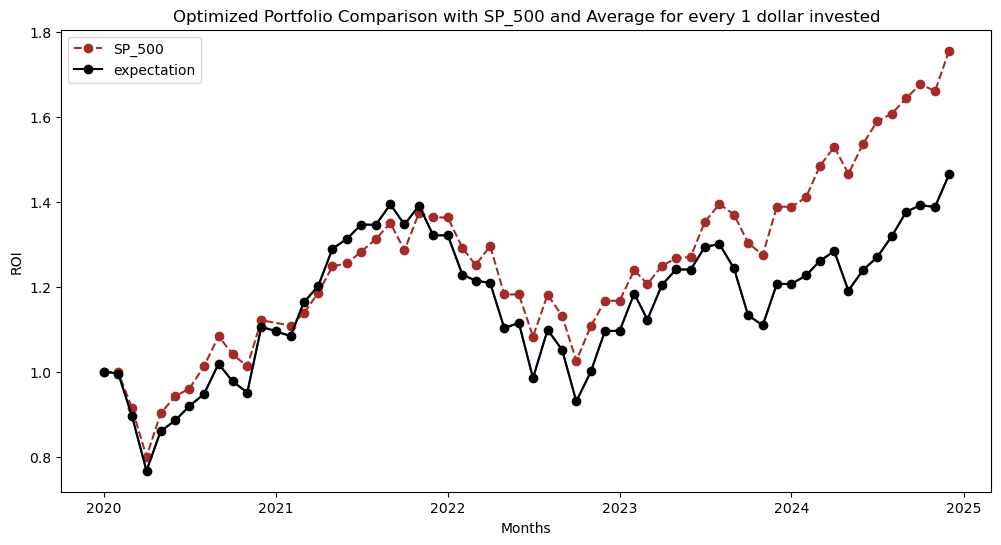

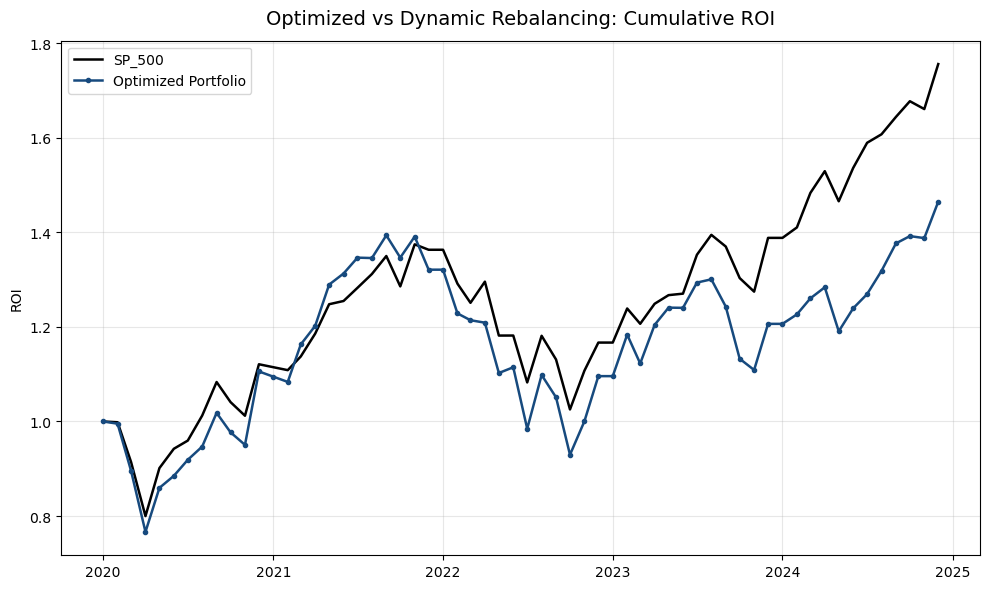

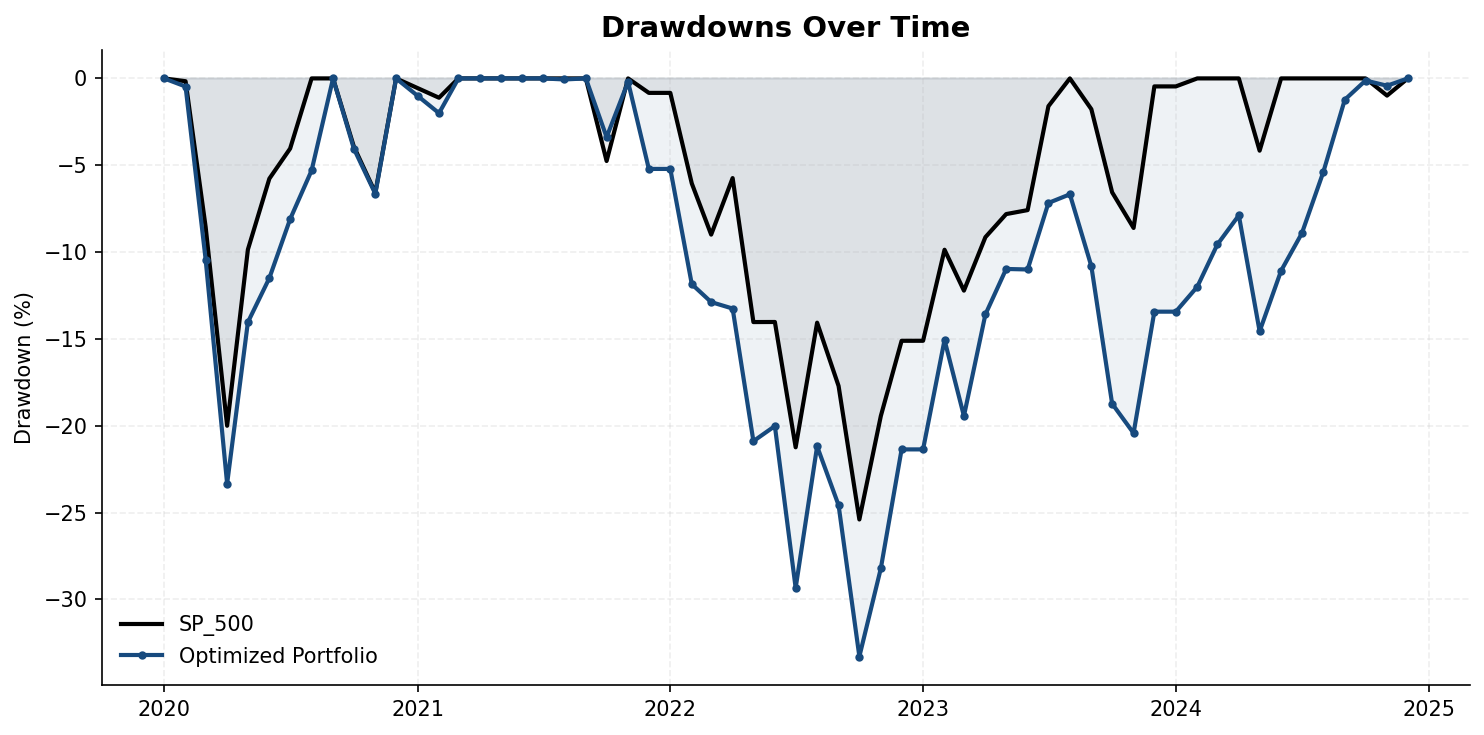

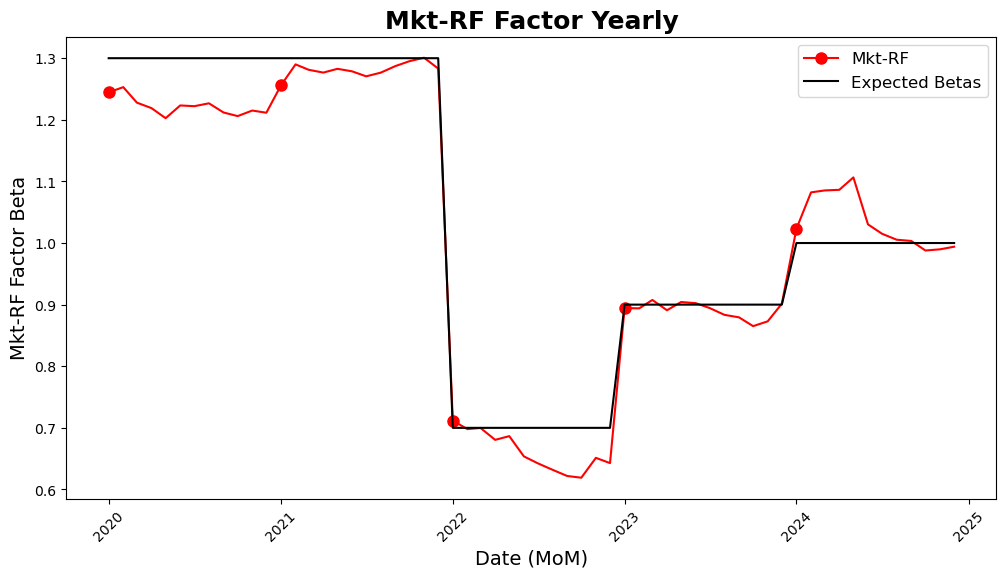

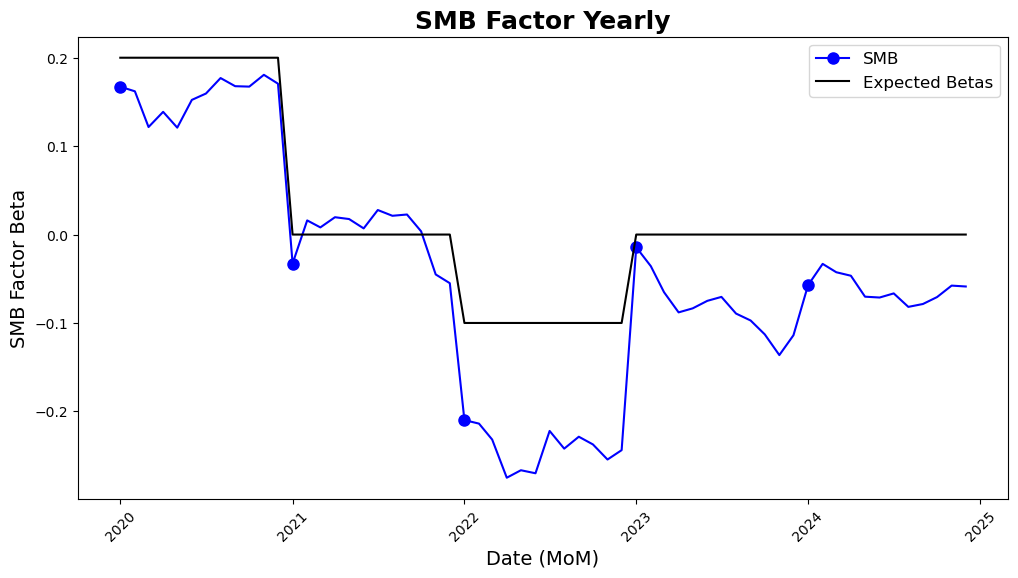

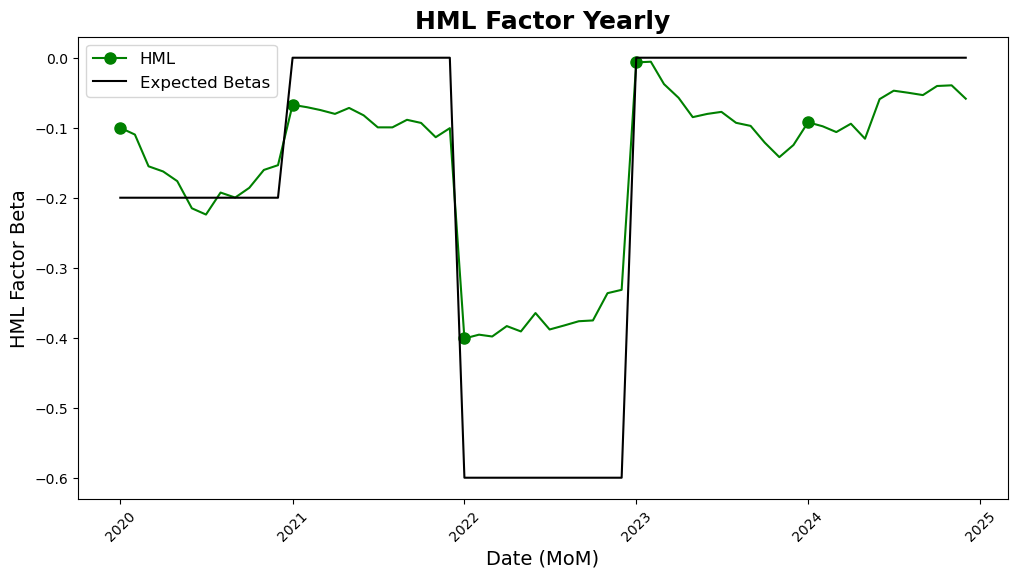

(              SP_500  Optimized Portfolio
 2020-02-01 -0.001628            -0.004671
 2020-03-01 -0.084110            -0.100088
 2020-04-01 -0.125119            -0.144127
 2020-05-01  0.126844             0.121328
 2020-06-01  0.045282             0.029549
 2020-07-01  0.018388             0.038358
 2020-08-01  0.055101             0.030486
 2020-09-01  0.070065             0.075193
 2020-10-01 -0.039228            -0.040417
 2020-11-01 -0.027666            -0.027133
 2020-12-01  0.107546             0.163334
 2021-01-01 -0.005568            -0.010013
 2021-02-01 -0.005600            -0.010115
 2021-03-01  0.026091             0.073031
 2021-04-01  0.042439             0.033832
 2021-05-01  0.052425             0.072545
 2021-06-01  0.005487             0.018175
 2021-07-01  0.022214             0.025551
 2021-08-01  0.022748            -0.000613
 2021-09-01  0.028990             0.035718
 2021-10-01 -0.047569            -0.033828
 2021-11-01  0.069144             0.032984
 2021-12-01

In [ ]:
# y = yearly rebalancing
# m = monthly rebalancing
# dry = dynamic rebalancing yearly
# drm = dynamic rebalancing monthly
# cv =  Cross Validation strategies & dynamic monthly rebalancing
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1, 0, 0 ,'rebalance',3,5, 'dry')
avg_dry = final_visual()
analyze_portfolios(avg_dry,12,'m')


In [305]:
old_b = []
for i,month in enumerate(rebalance_optimal_weights_appended.index):
        perfm = rebalance_optimal_weights_appended.loc[[month]]
        betas = to__cal_stock_betas_monthly(i,month,perfm)
        old_b.append(betas)


In [307]:
old_b

[Mkt-RF    1.244565
 SMB       0.167214
 HML      -0.100105
 dtype: float64,
 Mkt-RF    1.253015
 SMB       0.162019
 HML      -0.109773
 dtype: float64,
 Mkt-RF    1.227837
 SMB       0.121602
 HML      -0.155116
 dtype: float64,
 Mkt-RF    1.218915
 SMB       0.138776
 HML      -0.162497
 dtype: float64,
 Mkt-RF    1.202636
 SMB       0.120909
 HML      -0.176320
 dtype: float64,
 Mkt-RF    1.223307
 SMB       0.152306
 HML      -0.215086
 dtype: float64,
 Mkt-RF    1.222100
 SMB       0.159503
 HML      -0.224039
 dtype: float64,
 Mkt-RF    1.226766
 SMB       0.177008
 HML      -0.192629
 dtype: float64,
 Mkt-RF    1.211885
 SMB       0.167798
 HML      -0.199788
 dtype: float64,
 Mkt-RF    1.206017
 SMB       0.167324
 HML      -0.185859
 dtype: float64,
 Mkt-RF    1.215030
 SMB       0.180664
 HML      -0.160303
 dtype: float64,
 Mkt-RF    1.211485
 SMB       0.170610
 HML      -0.153524
 dtype: float64,
 Mkt-RF    1.255908
 SMB      -0.032755
 HML      -0.067292
 dtype: float64,

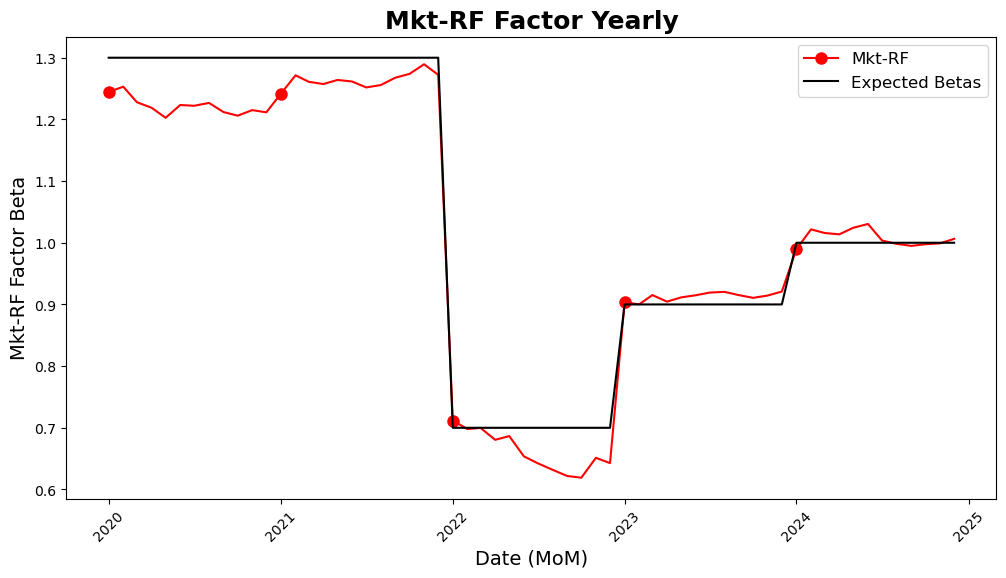

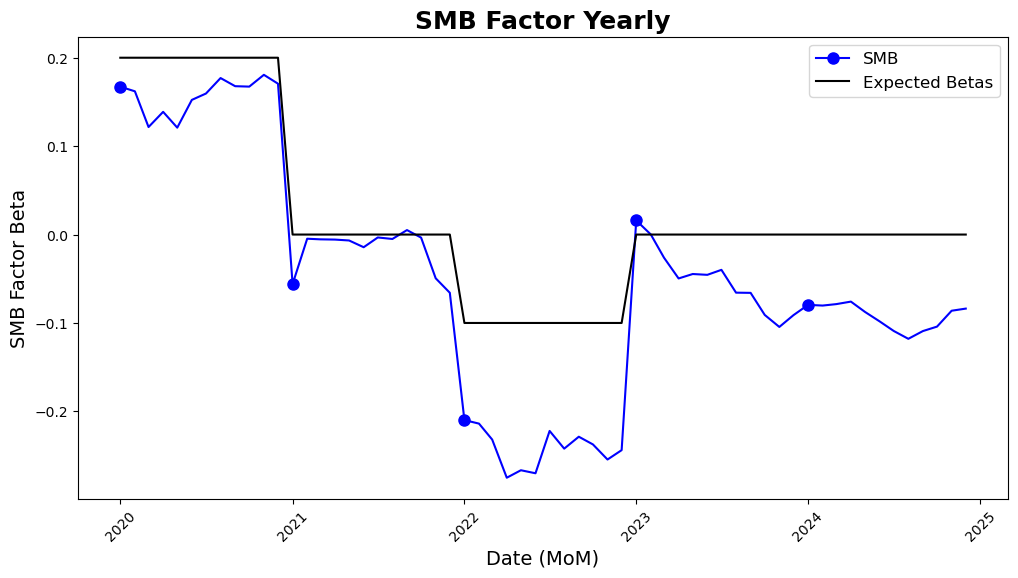

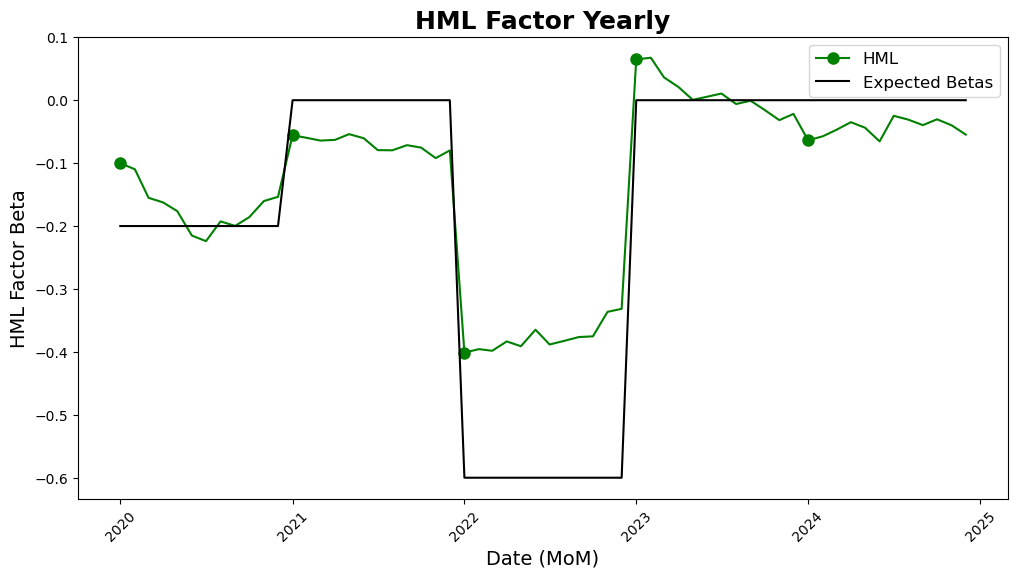

In [300]:
plot_yearly_betas()

In [299]:
def plot_yearly_betas():
    famafrenchreturns_FS()
    monthly_beta = []
    mark_every = 12 
    m_size = 8
    rebalanced_optimal_weights_y()
    n_p = 'Yearly'
    for i,month in enumerate(rebalance_optimal_weights_appended.index):
        perfm = rebalance_optimal_weights_appended.loc[[month]]
        betas = to__cal_stock_betas_monthly(i,month,perfm)
        monthly_beta.append(betas)
    fig, ax = plt.subplots(figsize=(12, 6))
    mkt_rf_a = [x[0] for x in monthly_beta]
    ax.plot(avg_dry.index, mkt_rf_a, label='Mkt-RF', color='red', marker = 'o', markersize=m_size, markevery=mark_every)
    mkt_rf_e = [x[0] for x in expected_betas]
    mkt_rf_e.append(mkt_rf_e[58])
    ax.plot(avg_dry.index, mkt_rf_e, label='Expected Betas', color='black')
    ax.set_xlabel('Date (MoM)', fontsize=14)
    ax.set_ylabel('Mkt-RF Factor Beta', fontsize = 14)
    ax.set_title(f'Mkt-RF Factor {n_p}', fontsize = 18, weight='bold')
    plt.xticks(rotation=45)
    ax.legend(fontsize=12)
    plt.show()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    smba = [x[1] for x in monthly_beta]
    ax.plot(avg_dry.index, smba, label='SMB', color='blue', marker = 'o', markersize=m_size, markevery=mark_every)
    smbe = [x[1] for x in expected_betas]
    smbe.append(smbe[58])
    ax.plot(avg_dry.index, smbe, label='Expected Betas', color='black')
    ax.set_xlabel('Date (MoM)', fontsize=14)
    ax.set_ylabel('SMB Factor Beta', fontsize = 14)
    ax.set_title(f'SMB Factor {n_p}', fontsize = 18, weight='bold')
    plt.xticks(rotation=45)
    ax.legend(fontsize=12)
    plt.show()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    hmla = [x[2] for x in monthly_beta]
    ax.plot(avg_dry.index, hmla, label='HML', color='green', marker = 'o', markersize=m_size, markevery=mark_every)
    hmle = [x[2] for x in expected_betas]
    hmle.append(hmle[58])
    ax.plot(avg_dry.index, hmle, label='Expected Betas', color='black')
    ax.set_xlabel('Date (MoM)', fontsize=14)
    ax.set_ylabel('HML Factor Beta', fontsize = 14)
    ax.set_title(f'HML Factor {n_p}', fontsize = 18, weight='bold')
    plt.xticks(rotation=45)
    ax.legend(fontsize=12)
    plt.show()
    

In [488]:
def tax_adjustment(perf_list, rebal_freq, monthly_returns):
    oos1_list_tax = monthly_returns.copy()
    rebal_l = rebalance_optimal_weights_appended.copy()
    total_term_tax = 0
    
    if rebal_freq == 'y':
        tax_rate = 0.15
        monthly_cumr = perf_list['Optimized Portfolio'] * 1000000
        for i in range(1, 5):
            j = i * 12
            old_weights = rebal_l.iloc[j-1]
            new_weights = rebal_l.iloc[j]
            delta_weights = (old_weights - new_weights).clip(lower=0)
            portf_val = monthly_cumr.iloc[j] - monthly_cumr.iloc[j-12]
            total_term_tax += sum(delta_weights) * portf_val * tax_rate
    
    if rebal_freq == 'm':
        short_term_tax_rate = 0.36
        long_term_tax_rate = 0.15
        monthly_cumr = perf_list['Optimized Portfolio'] * 1000000
        # Track cost basis for each position: {ticker: [(cost_basis, shares, purchase_month), ...]}
        position_lots = {}  # Will track lots using FIFO
        
        annual_net_gains = 0
        loss_carryforward = 0
        
        for j in range(1, 59):
            monthly_tax = 0
            old_weights = rebal_l.iloc[j-1]
            new_weights = rebal_l.iloc[j]
            
            portf_val_prev = monthly_cumr.iloc[j-1]
            portf_val_curr = monthly_cumr.iloc[j]
            
            # Step 1: Process sales (positions being reduced)
            delta_weights_sold = (old_weights - new_weights).clip(lower=0)
            positions_sold = delta_weights_sold[delta_weights_sold != 0]
            
            for ticker in positions_sold.index:
                # How much are we selling (in dollars)?
                amount_to_sell = portf_val_curr * positions_sold[ticker]
                
                # Get current price return
                t_return = float(new_monthly_data.iloc[j + 240].loc[ticker])
                current_price_factor = 1 + t_return  # Price multiplier from last month
                
                # Calculate gain using FIFO (First In, First Out)
                if ticker in position_lots and len(position_lots[ticker]) > 0:
                    remaining_to_sell = amount_to_sell
                    
                    while remaining_to_sell > 0 and len(position_lots[ticker]) > 0:
                        lot = position_lots[ticker][0]  # Get oldest lot (FIFO)
                        cost_basis_per_dollar, lot_value_at_purchase, purchase_month = lot
                        
                        # Update lot value to current price
                        # Calculate cumulative return from purchase to now
                        cumulative_return = 1.0
                        for k in range(purchase_month + 1, j + 1):
                            month_return = float(new_monthly_data.iloc[k + 240].loc[ticker])
                            cumulative_return *= (1 + month_return)
                        
                        current_lot_value = lot_value_at_purchase * cumulative_return
                        
                        if current_lot_value <= remaining_to_sell:
                            # Sell entire lot
                            sell_amount = current_lot_value
                            capital_gain = sell_amount - lot_value_at_purchase
                            
                            # Determine if long-term (>12 months) or short-term
                            holding_period = j - purchase_month
                            tax_rate = long_term_tax_rate if holding_period > 12 else short_term_tax_rate
                            
                            tax = capital_gain * tax_rate
                            monthly_tax += tax
                            
                            # Remove this lot
                            position_lots[ticker].pop(0)
                            remaining_to_sell -= sell_amount
                        else:
                            # Sell partial lot
                            sell_fraction = remaining_to_sell / current_lot_value
                            capital_gain = (remaining_to_sell - lot_value_at_purchase * sell_fraction)
                            
                            holding_period = j - purchase_month
                            tax_rate = long_term_tax_rate if holding_period > 12 else short_term_tax_rate
                            
                            tax = capital_gain * tax_rate
                            monthly_tax += tax
                            
                            # Update lot (reduce it)
                            new_lot_value = lot_value_at_purchase * (1 - sell_fraction)
                            position_lots[ticker][0] = (cost_basis_per_dollar, new_lot_value, purchase_month)
                            remaining_to_sell = 0
            
            # Step 2: Process purchases (positions being increased)
            delta_weights_bought = (new_weights - old_weights).clip(lower=0)
            positions_bought = delta_weights_bought[delta_weights_bought != 0]
            
            for ticker in positions_bought.index:
                # How much are we buying (in dollars)?
                purchase_amount = portf_val_curr * positions_bought[ticker]
                
                # Add new lot
                if ticker not in position_lots:
                    position_lots[ticker] = []
                
                position_lots[ticker].append((1.0, purchase_amount, j))
            
            # Accumulate gains for the year
            annual_net_gains += monthly_tax / short_term_tax_rate  # Convert tax back to gains
            
            # Debug output
            if j <= 12:
                print(f"Month {j}: monthly_tax=${monthly_tax:,.0f}, annual_net_gains=${annual_net_gains:,.0f}")
            
            # Year-end settlement
            if j % 12 == 0:
                print(f"\n=== YEAR {j//12} END ===")
                print(f"Annual gains: ${annual_net_gains:,.0f}")
                print(f"Loss carryforward: ${loss_carryforward:,.0f}")
                
                net_gain = annual_net_gains + loss_carryforward
                print(f"Net taxable gain: ${net_gain:,.0f}")
                
                if net_gain > 0:
                    # Use short-term rate for simplicity (can refine later)
                    tax_due = net_gain * short_term_tax_rate
                    ret_adj = tax_due / monthly_cumr.iloc[j]
                    oos1_list_tax.iloc[j, 1] = oos1_list_tax.iloc[j, 1] - ret_adj
                    total_term_tax += tax_due
                    loss_carryforward = 0
                    print(f"  → Tax due: ${tax_due:,.0f}")
                else:
                    loss_carryforward = net_gain
                    print(f"  → No tax, carry forward: ${loss_carryforward:,.0f}")
                
                annual_net_gains = 0
                print(f"  → Cumulative tax paid: ${total_term_tax:,.0f}\n")
        oos1_list_tax = oos1_list_tax.cumprod()
    
    return total_term_tax, oos1_list_tax

In [489]:
total_tax,oos1_list_tax = tax_adjustment(avg_drm,'m',monthly_returns)

Month 1: monthly_tax=$0, annual_net_gains=$0
Month 2: monthly_tax=$-29,468, annual_net_gains=$-81,856
Month 3: monthly_tax=$9,544, annual_net_gains=$-55,345
Month 4: monthly_tax=$10,201, annual_net_gains=$-27,010
Month 5: monthly_tax=$8,563, annual_net_gains=$-3,225
Month 6: monthly_tax=$14,249, annual_net_gains=$36,356
Month 7: monthly_tax=$8,957, annual_net_gains=$61,237
Month 8: monthly_tax=$7,695, annual_net_gains=$82,611
Month 9: monthly_tax=$-1,442, annual_net_gains=$78,605
Month 10: monthly_tax=$9,532, annual_net_gains=$105,083
Month 11: monthly_tax=$21,752, annual_net_gains=$165,505
Month 12: monthly_tax=$10,416, annual_net_gains=$194,439

=== YEAR 1 END ===
Annual gains: $194,439
Loss carryforward: $0
Net taxable gain: $194,439
  → Tax due: $69,998
  → Cumulative tax paid: $69,998


=== YEAR 2 END ===
Annual gains: $279,672
Loss carryforward: $0
Net taxable gain: $279,672
  → Tax due: $100,682
  → Cumulative tax paid: $170,680


=== YEAR 3 END ===
Annual gains: $-116,658
Loss 

(              SP_500  Optimized Portfolio
 Date                                     
 2020-02-01 -0.001628            -0.024129
 2020-03-01 -0.084110            -0.055616
 2020-04-01 -0.125119            -0.177789
 2020-05-01  0.126844             0.163236
 2020-06-01  0.045282             0.068902
 2020-07-01  0.018388             0.014637
 2020-08-01  0.055101             0.049617
 2020-09-01  0.070065             0.082393
 2020-10-01 -0.039228            -0.024480
 2020-11-01 -0.027666            -0.038895
 2020-12-01  0.107546             0.120591
 2021-01-01  0.037121            -0.011679
 2021-02-01 -0.011137            -0.025081
 2021-03-01  0.026091             0.077102
 2021-04-01  0.042439             0.047285
 2021-05-01  0.052425             0.060774
 2021-06-01  0.005487             0.018701
 2021-07-01  0.022214             0.014125
 2021-08-01  0.022748             0.040930
 2021-09-01  0.028990             0.022516
 2021-10-01 -0.047569            -0.037072
 2021-11-01

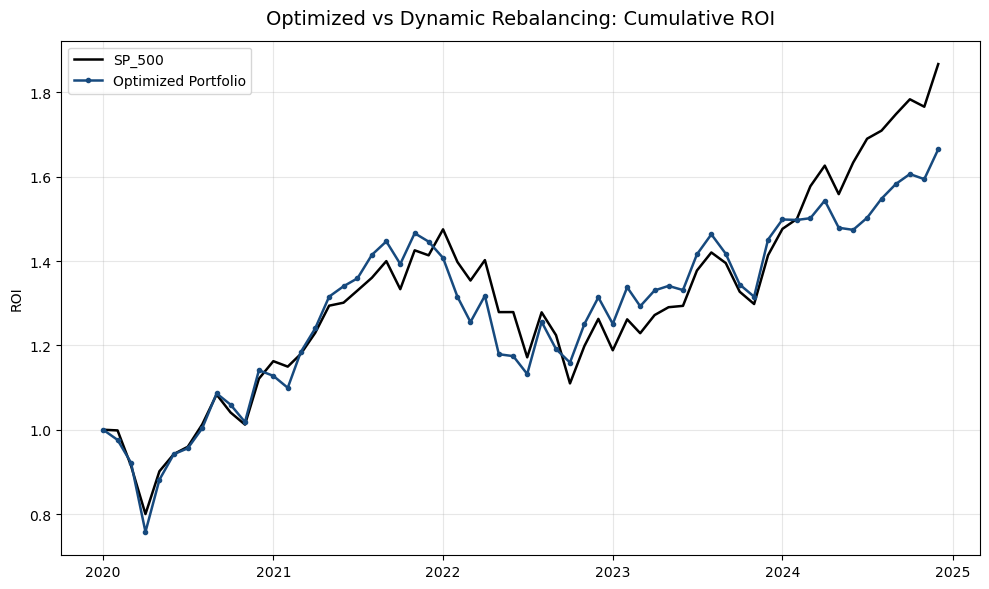

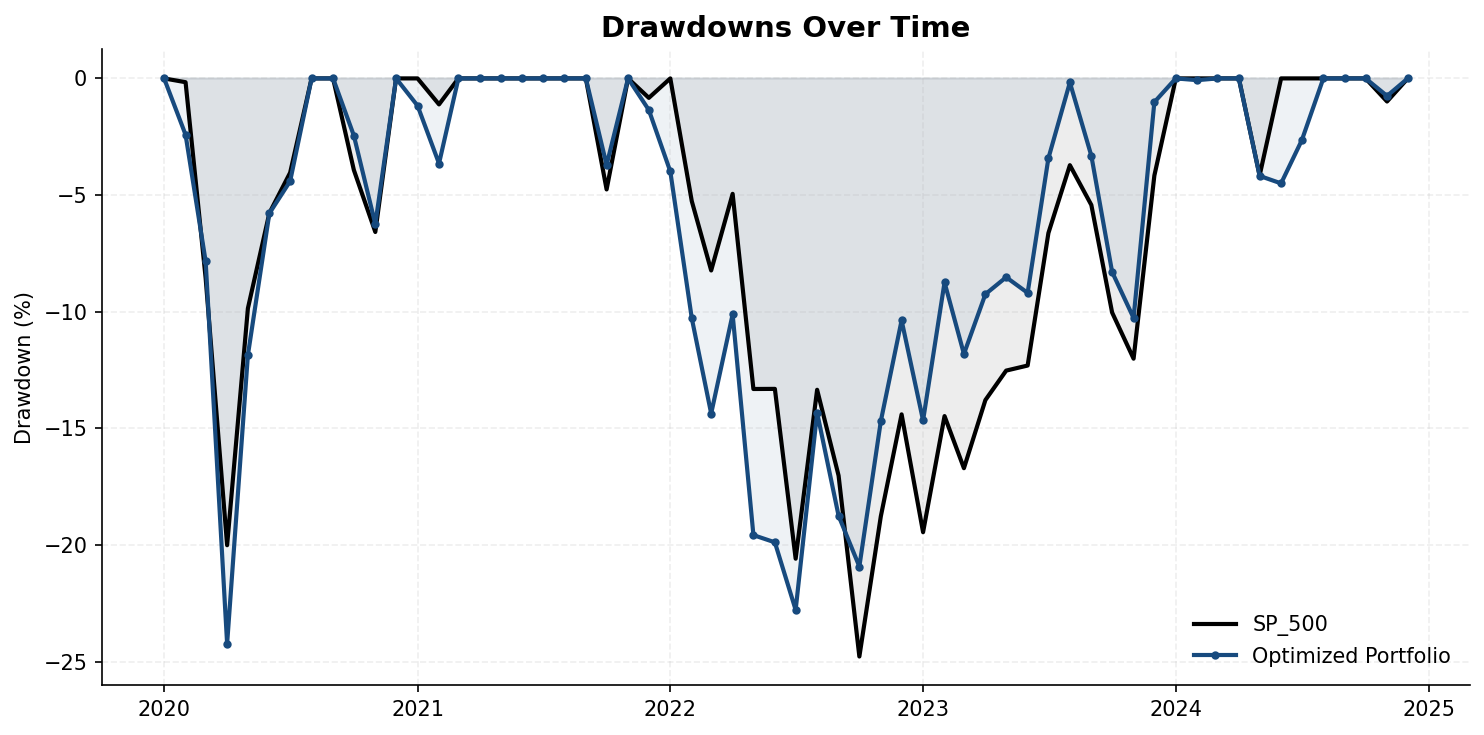

In [490]:
analyze_portfolios(oos1_list_tax,12)

In [83]:
df = pd.read_csv('yrebal_explored_sortino_o1_2021.csv')
df = df.drop(columns = ['std', 'return'])

VARIANCE INFLATION FACTOR (VIF) - Multicollinearity Check
Variable      VIF
      c1 1.116936
      c2 1.050264
      c3 1.005181
  reward 1.096641

Interpretation:
  VIF = 1: No correlation
  VIF < 5: Low multicollinearity (acceptable)
  VIF > 5: High multicollinearity (problematic)
  VIF > 10: Severe multicollinearity (remove variable)

EIGENVALUE ANALYSIS
Eigenvalue 1: 1.794839
Eigenvalue 2: 1.013802
Eigenvalue 3: 0.997534
Eigenvalue 4: 0.193825

Condition Number: 9.26
Interpretation:
  < 10: No multicollinearity
  10-30: Moderate multicollinearity
  > 30: Severe multicollinearity

DETAILED CORRELATION ANALYSIS

High Correlations (|r| > 0.7):
Var1   Var2  Correlation  Abs_Correlation
  c1 reward     0.791386         0.791386
REWARD CORRELATIONS
c1          :  0.7914
c2          :  0.0722
c3          : -0.0735



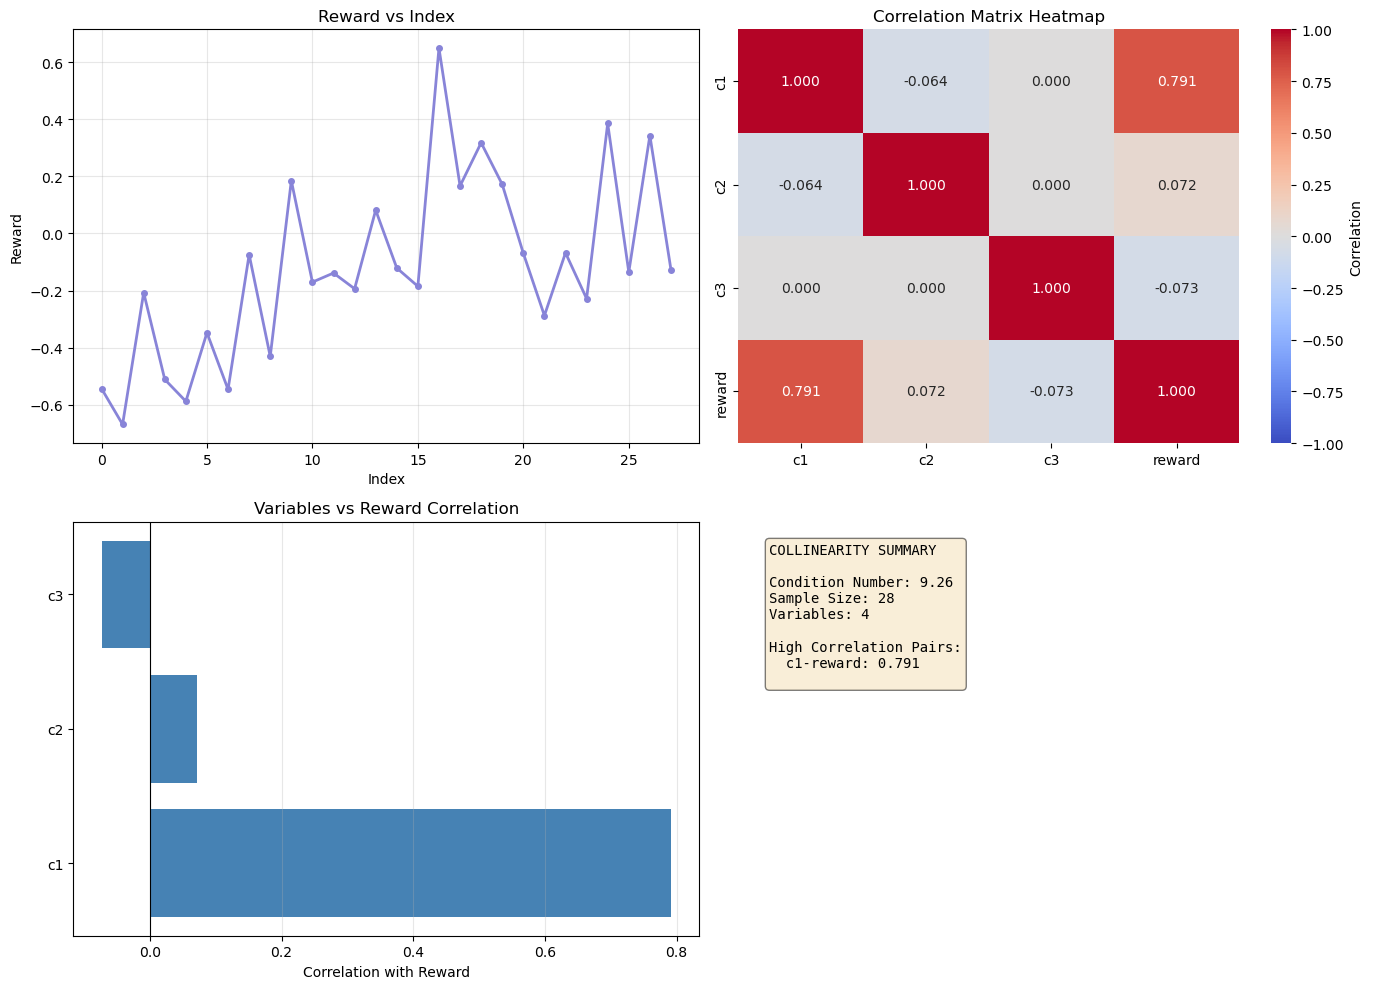

FULL CORRELATION MATRIX
                  c1            c2            c3    reward
c1      1.000000e+00 -6.356831e-02  2.836789e-17  0.791386
c2     -6.356831e-02  1.000000e+00  9.860523e-18  0.072191
c3      2.836789e-17  9.860523e-18  1.000000e+00 -0.073473
reward  7.913855e-01  7.219070e-02 -7.347312e-02  1.000000



In [84]:
df['index']= range(len(df))
# ============================================
# 1. PLOT: Reward vs Index
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Reward vs Index
axes[0, 0].plot(df['index'], df['reward'], marker='o', linestyle='-', linewidth=2, markersize=4, color='#8884d8')
axes[0, 0].set_xlabel('Index')
axes[0, 0].set_ylabel('Reward')
axes[0, 0].set_title('Reward vs Index')
axes[0, 0].grid(True, alpha=0.3)

# ============================================
# 2. CORRELATION MATRIX & HEATMAP
# ============================================
variables = ['c1', 'c2', 'c3', 'reward']
corr_matrix = df[variables].corr()

# Subplot 2: Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            ax=axes[0, 1], vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
axes[0, 1].set_title('Correlation Matrix Heatmap')

# ============================================
# 3. VARIANCE INFLATION FACTOR (VIF)
# ============================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each variable
X = df[['c1', 'c2', 'c3', 'reward']]
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("=" * 60)
print("VARIANCE INFLATION FACTOR (VIF) - Multicollinearity Check")
print("=" * 60)
print(vif_data.to_string(index=False))
print("\nInterpretation:")
print("  VIF = 1: No correlation")
print("  VIF < 5: Low multicollinearity (acceptable)")
print("  VIF > 5: High multicollinearity (problematic)")
print("  VIF > 10: Severe multicollinearity (remove variable)")
print()

# ============================================
# 4. CONDITION NUMBER & EIGENVALUES
# ============================================
# Standardize the data for eigenvalue analysis
X_standardized = (X - X.mean()) / X.std()
cov_matrix = X_standardized.cov()
eigenvalues = np.linalg.eigvals(cov_matrix)
eigenvalues = np.sort(eigenvalues)[::-1]
condition_number = eigenvalues[0] / eigenvalues[-1]

print("=" * 60)
print("EIGENVALUE ANALYSIS")
print("=" * 60)
for i, ev in enumerate(eigenvalues):
    print(f"Eigenvalue {i+1}: {ev:.6f}")
print(f"\nCondition Number: {condition_number:.2f}")
print("Interpretation:")
print("  < 10: No multicollinearity")
print("  10-30: Moderate multicollinearity")
print("  > 30: Severe multicollinearity")
print()

# ============================================
# 5. DETAILED CORRELATION ANALYSIS
# ============================================
print("=" * 60)
print("DETAILED CORRELATION ANALYSIS")
print("=" * 60)

# Find high correlations (excluding diagonal)
high_corr_pairs = []
for i in range(len(variables)):
    for j in range(i+1, len(variables)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:  # Threshold for "high" correlation
            high_corr_pairs.append({
                'Var1': variables[i],
                'Var2': variables[j],
                'Correlation': corr_val,
                'Abs_Correlation': abs(corr_val)
            })
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['Var1', 'Var2', 'Correlation', 'Abs_Correlation']
).sort_values('Abs_Correlation', ascending=False)
print("\nHigh Correlations (|r| > 0.7):")
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))
else:
    print("No high correlations detected.")

# ============================================
# 6. REWARD-SPECIFIC CORRELATIONS
# ============================================
print("=" * 60)
print("REWARD CORRELATIONS")
print("=" * 60)
reward_corrs = corr_matrix['reward'].sort_values(ascending=False)
for var, corr in reward_corrs.items():
    if var != 'reward':
        print(f"{var:12s}: {corr:7.4f}")
print()

# Subplot 3: Reward correlations bar chart
axes[1, 0].barh(reward_corrs[reward_corrs.index != 'reward'].index, 
                reward_corrs[reward_corrs.index != 'reward'].values, color='steelblue')
axes[1, 0].set_xlabel('Correlation with Reward')
axes[1, 0].set_title('Variables vs Reward Correlation')
axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Subplot 4: Full correlation matrix as text
axes[1, 1].axis('off')
summary_text = "COLLINEARITY SUMMARY\n\n"
summary_text += f"Condition Number: {condition_number:.2f}\n"
summary_text += f"Sample Size: {len(df)}\n"
summary_text += f"Variables: {len(variables)}\n\n"
summary_text += "High Correlation Pairs:\n"
if len(high_corr_df) > 0:
    for _, row in high_corr_df.head(5).iterrows():
        summary_text += f"  {row['Var1']}-{row['Var2']}: {row['Correlation']:.3f}\n"
else:
    summary_text += "  None detected\n"

axes[1, 1].text(0.05, 0.95, summary_text, transform=axes[1, 1].transAxes, 
               fontsize=10, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('reward_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# PRINT FULL CORRELATION MATRIX
# ============================================
print("=" * 60)
print("FULL CORRELATION MATRIX")
print("=" * 60)
print(corr_matrix.to_string())
print()

Column 'FTI' could not be converted to float.
1.3, 0.2, -0.2 
Column 'FTI' could not be converted to float.
1.3, 0.0, 0.0 
0.7, -0.1, -0.6 
0.9, 0.0, 0.0 
1.0, 0.0, 0.0 
1.3, 0.2, -0.2 
1.3, 0.0, 0.0 
0.7, -0.1, -0.6 
0.9, 0.0, 0.0 
1.0, 0.0, 0.0 


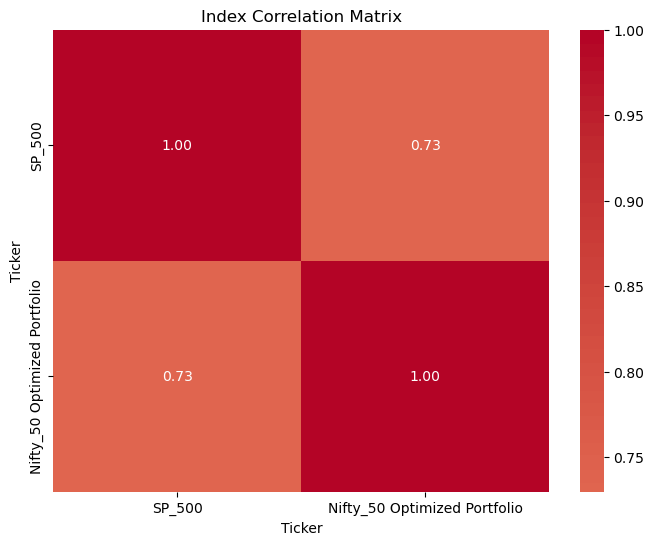

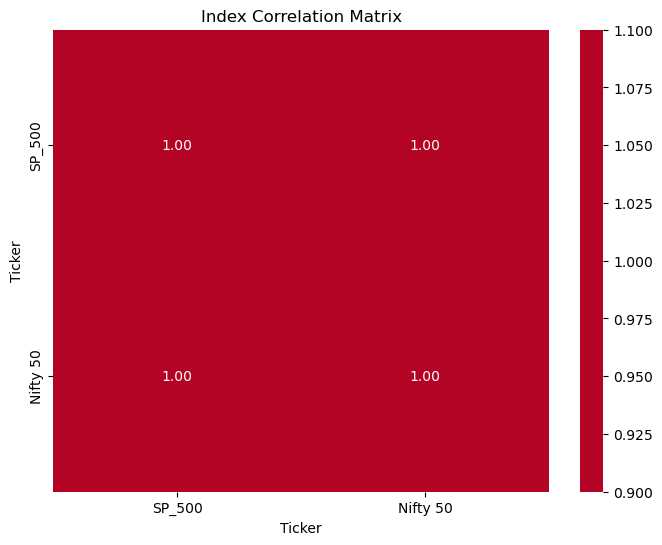

In [ ]:

new_data1, indexgspc1, spy_yoy_tickers1 = run_sp500_data()
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1, 0, 0 ,'rebalance',3,5, 'dry')
s_5 = oos1_list[0]
new_data1, indexgspc1, spy_yoy_tickers1 = run_N50_data()
oos1_list1,oos1_list_yearly1,oos1_average1=monte_carlo_simulation(1,1, 0, 0 ,'rebalance',3,5, 'dry')
n_5 = oos1_list1[0]

oos1_list[0] = oos1_list[0].rename(columns={'Optimized Portfolio':'SP_500 Optimized Portfolio'})
oos1_list1[0] = oos1_list1[0].rename(columns={'Optimized Portfolio':'Nifty_50 Optimized Portfolio'})
oos1_list1[0]['SP_500'] = oos1_list[0]['SP_500 Optimized Portfolio'] 
mr = oos1_list1[0]

n_5 = n_5.rename(columns={'SP_500':'Nifty 50'})
s_5['Optimized Portfolio'] = n_5['Nifty 50']
index_r = s_5.rename(columns={'Optimized Portfolio':'Nifty 50'})

corr = mr.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Index Correlation Matrix")
plt.show()

corr = index_r.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Index Correlation Matrix")
plt.show()

In [ ]:
# y = yearly rebalancing
# m = monthly rebalancing
# dry = dynamic rebalancing yearly
# drm = dynamic rebalancing monthly

oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,0.8,0.1,0.0,'rebalance',3,5, 'm')

Column 'FTI' could not be converted to float.


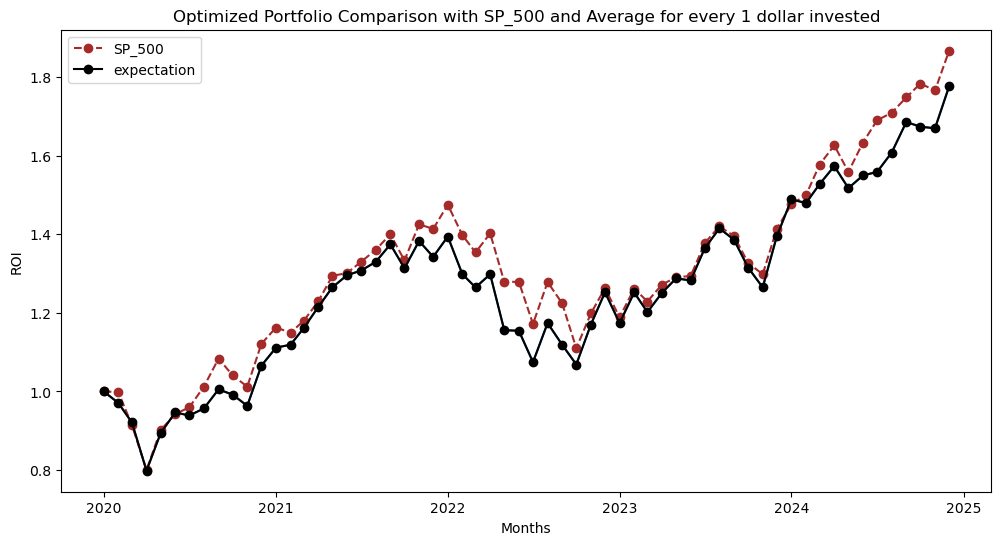

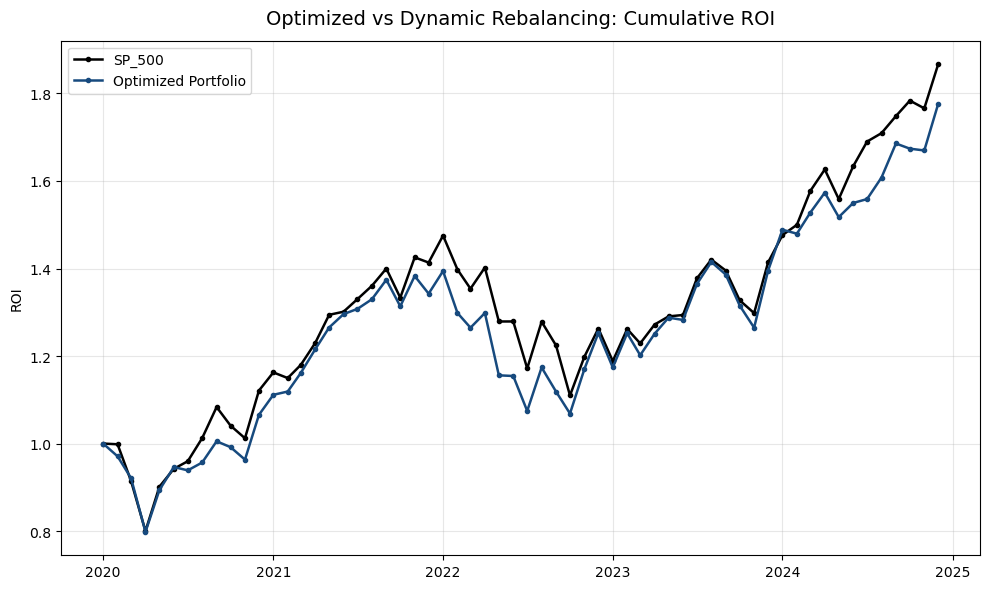

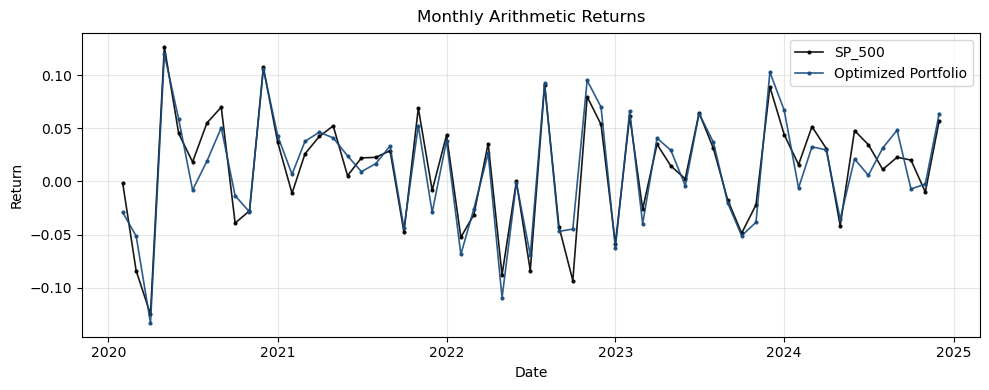

(              SP_500  Optimized Portfolio
 Date                                     
 2020-02-01 -0.001628            -0.029179
 2020-03-01 -0.084110            -0.051397
 2020-04-01 -0.125119            -0.133303
 2020-05-01  0.126844             0.119875
 2020-06-01  0.045282             0.058770
 2020-07-01  0.018388            -0.008043
 2020-08-01  0.055101             0.019126
 2020-09-01  0.070065             0.050644
 2020-10-01 -0.039228            -0.013340
 2020-11-01 -0.027666            -0.028678
 2020-12-01  0.107546             0.106112
 2021-01-01  0.037121             0.043013
 2021-02-01 -0.011137             0.006779
 2021-03-01  0.026091             0.037864
 2021-04-01  0.042439             0.046489
 2021-05-01  0.052425             0.041082
 2021-06-01  0.005487             0.024176
 2021-07-01  0.022214             0.009266
 2021-08-01  0.022748             0.016808
 2021-09-01  0.028990             0.033501
 2021-10-01 -0.047569            -0.044190
 2021-11-01

In [ ]:
analyze_portfolios(final_visual(),.00209)

# Reinforcement Learning
### Skip this if not using 

In [86]:
# So remeber the syntax, where the 3, 8 would be 3 years of validation for the next 8 years of performance (2024-8 = 2016)
# so for this example, 8 would be 2016-2024, and the 3 would be 2014,2015,2016.
# The final input is adjustment factor, which means what data your cutting off, so at 5 that means cut off at 2019 (2024-5=2019), 
# so the validation would be the 2017,2018,2019


monte_carlo_simulation_rlm(1,1, 0, 0,'rebalance', 3,7, 'y',4)


get_spy2                      0.613 s
fama_french_returns           0.009 s
to_cal_stock_price            0.322 s
Transaction_Costs             0.000 s
optimization                  0.937 s
others                        0.560 s
portfolio_betas               0.103 s
****************** Training Period: **********************
2015-01-01
2017-12-31 00:00:00

get_spy2                      0.539 s
fama_french_returns           0.009 s
to_cal_stock_price            0.384 s
Transaction_Costs             0.000 s
optimization                  0.902 s
others                        0.539 s
portfolio_betas               0.093 s
****************** Training Period: **********************
2016-01-01
2018-12-31 00:00:00

get_spy2                      0.559 s
fama_french_returns           0.009 s
to_cal_stock_price            0.311 s
Transaction_Costs             0.000 s
optimization                  0.855 s
others                        0.608 s
portfolio_betas               0.123 s
****************** 

([Ticker        SP_500  Optimized Portfolio
  Date                                     
  2018-01-01  1.000000             1.000000
  2018-02-01  1.056179             1.045617
  2018-03-01  1.015044             1.008566
  2018-04-01  0.987755             1.005277
  2018-05-01  0.990440             1.005675
  2018-06-01  1.011842             1.015240
  2018-07-01  1.016741             1.016959
  2018-08-01  1.053366             1.067636
  2018-09-01  1.085244             1.077396
  2018-10-01  1.089904             1.082777
  2018-11-01  1.014261             0.999060
  2018-12-01  1.032375             1.053202
  2019-02-01  1.113607             1.146344
  2019-03-01  1.146713             1.173165
  2019-04-01  1.167267             1.178652
  2019-05-01  1.213155             1.221852
  2019-06-01  1.133357             1.140290
  2019-07-01  1.211479             1.216722
  2019-08-01  1.227383             1.224896
  2019-09-01  1.205177             1.174678
  2019-10-01  1.225883          

In [87]:
def get_consistently_worst_portfolio(dfs, portfolio_col='portfolio'):
    """
    Returns the DataFrame whose portfolio is consistently the worst performer.

    Parameters:
        dfs (list of pd.DataFrame): Each must have a 'portfolio' and 'sp500' column.
        portfolio_col (str): The portfolio column name.

    Returns:
        pd.DataFrame: The worst performing portfolio's full DataFrame.
    """

    # Extract portfolio series and align them
    portfolio_series_list = [df[portfolio_col] for df in dfs]

    # Get the common index (intersection of all time indices)
    common_index = set(portfolio_series_list[0].index)
    for series in portfolio_series_list[1:]:
        common_index &= set(series.index)
    common_index = sorted(common_index)

    # Reindex all series to the common index
    aligned_series = [s.loc[common_index] for s in portfolio_series_list]

    # Combine into a single DataFrame and give column names as their list indices
    combined_portfolios = pd.concat(aligned_series, axis=1)
    combined_portfolios.columns = list(range(len(dfs)))  # [0, 1, 2, ...]

    # Count how often each column has the minimum value across rows
    min_indices = combined_portfolios.idxmin(axis=1)
    min_counts = min_indices.value_counts()

    # Find the column (index) that was the minimum most often
    worst_index = min_counts.idxmax()

    # Return the corresponding original DataFrame
    return dfs[worst_index]

In [106]:
oos1_list, avg, fin = monte_carlo_simulation(1,1.3,0.1,0.1, 'rebalance',3,5,'y')

Column 'FTI' could not be converted to float.
Column 'FTI' could not be converted to float.


In [107]:
df = oos1_list[0].iloc[13:24]

In [89]:
import numpy as np
import pandas as pd
import os

class AdaptiveBandit:
    def __init__(self, target_years=5, objective='Sortino'):
        self.target_years = target_years
        self.objective = objective.lower()
   
        self.best_combination = np.array([1, 0, 0])
        self.best_return = -np.inf
        self.storage_file = f"yrebal_explored_{self.objective}_o1_2021_check.csv"  #change this for each new df 
        self.explored = self.load_explored_combinations()
    def load_explored_combinations(self):
        if os.path.exists(self.storage_file):
            df = pd.read_csv(self.storage_file)
            df[['c1', 'c2', 'c3', 'reward','return','std']] = df[['c1', 'c2', 'c3', 'reward','return','std']].astype(float)
            return df
        return pd.DataFrame(columns=['c1', 'c2', 'c3', 'reward','return','std'])
    def save_combination(self, combination, reward, returns, std):
        combination = self.round_combination(combination)
        reward = float(reward)
        returns = float(returns)
        std = float(std)

        # already seen?
        if self.check_existing_combination(combination) is not None:
            return

        new_entry = pd.DataFrame([{
            'c1': combination[0],
            'c2': combination[1],
            'c3': combination[2],
            'reward': reward,
            'return': returns,
            'std': std
        }])
        self.explored = pd.concat([self.explored, new_entry], ignore_index=True)
        self.explored.to_csv(self.storage_file, index=False)



    def check_existing_combination(self, combination):
        combination = self.round_combination(combination)
        match = self.explored[
            (self.explored['c1'] == combination[0]) &
            (self.explored['c2'] == combination[1]) &
            (self.explored['c3'] == combination[2])
        ]
        if not match.empty:
            return match.iloc[0]['reward']
        return None

    def round_combination(self, combination):
        return np.round(np.array(combination, dtype=float), 1)



    def evaluate_combination(self, beta_combination):
        betaa = beta_combination[0]
        betab = beta_combination[1]
        betac = beta_combination[2]
        oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation_rlm(2,betaa, betab, betac,'rebalance', 3,7, 'y',4) # change this to adjust training/validation sets
        if self.objective == 'max_return':
            simulated_df = final_visual()
        else:
            simulated_df = get_consistently_worst_portfolio(oos1_list, 'Optimized Portfolio')
        return simulated_df

    def reward_function(self, simulated_df):
        if self.objective in ['max_return']:
            returns_spy = simulated_df['SP_500'].pct_change().dropna()
            returns_opt = simulated_df['Optimized Portfolio'].pct_change().dropna()

            cum_ret_spy = (1 + returns_spy).prod() - 1
            cum_ret_opt = (1 + returns_opt).prod() - 1

            # Reward = excess cumulative return vs S&P
            reward = cum_ret_opt - cum_ret_spy

            
            returns = simulated_df['Optimized Portfolio'].iloc[-1]
            std =  simulated_df['Optimized Portfolio'].std()

            return reward,returns, std
        
        elif self.objective == 'sharpe':
            #need to fill 
            print("WORK IN PROGRESS")
        elif self.objective == 'sortino':
            rf_annual = .0501
            rf_monthly = (1 + rf_annual)**(1/12) - 1

            ret_spy = simulated_df['SP_500'].pct_change().dropna()
            ret_opt = simulated_df['Optimized Portfolio'].pct_change().dropna()

            active = (ret_opt - rf_monthly) - (ret_spy - rf_monthly)  # rf cancels anyway
            # equivalently: active = ret_opt - ret_spy

            downside_active = active[active < 0]
            downside_vol_active = np.sqrt((downside_active**2).mean()) * np.sqrt(12)

            mean_active = active.mean() * 12

            sortino_active = mean_active / downside_vol_active

            reward = sortino_active
            returns = simulated_df['Optimized Portfolio'].iloc[-1]
            std = ret_opt.std()
            print('****************** Validation Period: **********************')
            print(simulated_df.index[0])         
            print(simulated_df.index[-1])
            return reward,returns, std
        
        elif self.objective == 'volatility':
            returns_spy = simulated_df['SP_500'].pct_change().dropna()
            returns_opt = simulated_df['Optimized Portfolio'].pct_change().dropna()

            vol_spy = returns_spy.std() * np.sqrt(12)
            vol_opt = returns_opt.std() * np.sqrt(12)

            # Option A: ratio (similar to your old downside_vol ratio)
            reward = vol_spy / vol_opt  # >1 means lower vol than SP500

            # Option B: difference
            # reward = vol_spy - vol_opt  # positive = lower vol
            returns = simulated_df['Optimized Portfolio'].iloc[-1]
            std = ret_opt.std()
            return reward,returns, std
        
        else:
            raise ValueError(f"Unknown objective: {self.objective}")

  
    def explore_direction(self, base_combination):
        candidates = []
        directions = [-0.1, 0.1]
        lower_bounds = np.array([0.7, -0.6, -0.6])
        upper_bounds = np.array([1.3, 0.6, 0.6])
        found_new = False

        for i in range(3):
            for delta in directions:
                new_combination = base_combination.copy()
                new_combination[i] += delta
                new_combination = np.clip(new_combination, lower_bounds, upper_bounds)

                if self.check_existing_combination(new_combination) is not None:
                    continue  # Already explored, skip it

                new_combination = np.round(new_combination, 1)
                simulated_df = self.evaluate_combination(new_combination)
                reward,returns,std = self.reward_function(simulated_df)
                self.save_combination(new_combination, reward,returns,std)
                candidates.append((new_combination, reward))
                found_new = True
        

        return candidates, found_new

    def select_next_combination(self):
        candidates, found_new = self.explore_direction(self.best_combination)

        if not candidates:
            return self.best_combination, False  # No new exploration found

        candidates.sort(key=lambda x: x[1], reverse=True)
        best_candidate, best_reward = candidates[0]

        if best_reward > self.best_return:
            self.best_combination = best_candidate
            self.best_return = best_reward

        return self.best_combination, found_new
    
    def run_bandit(self, iterations, initializer):
        print(f"Running bandit optimization for objective: '{self.objective}'")

    # Base initialization
        if initializer == 'yes':
            base = np.array([1.0, 0.0, 0.0])
        else:
            if not self.explored.empty:
                best_row = self.explored.loc[self.explored['reward'].idxmax()]
                base = np.array([best_row['c1'], best_row['c2'], best_row['c3']])
            else:
                print("No previous data found. Using default base combination.")
                base = np.array([1.0, 0.0, 0.0])

    # Evaluate base combo
        reward = self.check_existing_combination(base)
        if reward is None:
            simulated_df = self.evaluate_combination(base)
            reward,returns,std = self.reward_function(simulated_df)
            self.save_combination(base, reward,returns,std)

        self.best_combination = base
        self.best_return = reward

        print(f"Base Combination: {self.best_combination}, Base Score: {self.best_return:.4f}")

        valid_iterations = 0
        attempt_cap = iterations * 10  # Avoid infinite loops

        while valid_iterations < iterations and attempt_cap > 0:
            new_combination, found_new = self.select_next_combination()
            attempt_cap -= 1

            if found_new:
                valid_iterations += 1
                print(f"[{valid_iterations}] New Combo: {new_combination} → Score: {self.best_return:.4f}")
            else:
              #  print("No new combination found. Expanding search...")
                continue
            # Optional: add random direction or noise when stuck
            random_combo = self.best_combination + np.random.uniform(-0.1, 0.1, size=3)
            random_combo = np.clip(random_combo, [0.7, -0.6, -0.6], [1.3, 0.6, 0.6])

            if self.check_existing_combination(random_combo) is None:
                simulated_df = self.evaluate_combination(random_combo)
                reward, returns, std = self.reward_function(simulated_df)
                self.save_combination(random_combo, reward, returns, std)

                if reward > self.best_return:
                    self.best_combination = random_combo
                    self.best_return = reward
                    valid_iterations += 1
                    print(f"[{valid_iterations}] Random Exploration: {random_combo} → Score: {self.best_return:.4f}")

        print("\nFinal Best Combination:")
        print(f"{self.best_combination} → Score: {self.best_return:.4f}")


bandit = AdaptiveBandit(objective='sortino')  # or 'max_return', 'sortino', etc.
bandit.run_bandit(iterations=100,initializer='Yes')  # You can set iterations to whatever you want 
# is max space iterations



Running bandit optimization for objective: 'sortino'
No previous data found. Using default base combination.

get_spy2                      0.532 s
fama_french_returns           0.008 s
to_cal_stock_price            0.316 s
Transaction_Costs             0.000 s
optimization                  1.157 s
others                        0.659 s
portfolio_betas               0.098 s
****************** Training Period: **********************
2015-01-01
2017-12-31 00:00:00

get_spy2                      0.563 s
fama_french_returns           0.012 s
to_cal_stock_price            0.451 s
Transaction_Costs             0.000 s
optimization                  0.897 s
others                        0.556 s
portfolio_betas               0.093 s
****************** Training Period: **********************
2016-01-01
2018-12-31 00:00:00

get_spy2                      0.561 s
fama_french_returns           0.008 s
to_cal_stock_price            0.318 s
Transaction_Costs             0.000 s
optimization            